# Revealing Causal Structure in AGN Reverberation Mapping with Information Decomposition (SURD)

Reverberation mapping of active galactic nuclei (AGN) has traditionally relied on cross-correlation techniques to infer time delays between continuum and emission-line variability, providing constraints on the geometry of the broad-line region. However, these methods are inherently limited to pairwise correlations and cannot disentangle the relative contributions of multiple, potentially redundant or synergistic driving signals across different wavebands.

In this work, we introduce an information-theoretic framework based on Synergistic–Unique–Redundant Decomposition (SURD) to analyse multi-band AGN light curves and quantify the causal structure underlying their variability. By decomposing the mutual information between future emission-line flux and present continuum signals into unique, redundant, and synergistic components, we construct a model-independent map of information flow across wavelengths and time lags.

We validate the method using controlled synthetic systems representing single-driver, redundant-proxy, and genuinely synergistic scenarios, demonstrating that SURD robustly recovers the expected information structure in each case. We then apply this framework to AGN reverberation mapping data, resampling irregularly sampled light curves onto a uniform grid and performing a systematic lag scan to identify the dominant channels of information transfer.

Our results show that traditional lag estimates can be complemented by a richer characterisation of variability, revealing whether different continuum bands provide independent constraints on the emission-line response or simply trace a common hidden driver. This approach opens a new avenue for probing the physical origin of AGN variability and for testing multi-component accretion and reprocessing models beyond standard correlation-based analyses.

### STEP 1: Mount Google Drive and Extract Project Files

First, we'll mount your Google Drive to access the `agn_surd_project.zip` file. Then, we'll create the target directory `/content/agn_surd_project/` and safely extract the contents of the ZIP file into it. This ensures all your project data and scripts are in a well-defined location.

In [10]:
from google.colab import drive
import os

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define paths
zip_file_path = '/content/drive/MyDrive/SURDS/agn_surd_project.zip'
extraction_path = '/content/agn_surd_project/'

# Create extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)
print(f"Created extraction directory: {extraction_path}")

# Extract the ZIP file
if os.path.exists(zip_file_path):
    print(f"Extracting {zip_file_path} to {extraction_path}...")
    !unzip -q "{zip_file_path}" -d "{extraction_path}"
    print("Extraction complete.")
else:
    print(f"Error: ZIP file not found at {zip_file_path}. Please ensure the path is correct and the file exists.")


Mounting Google Drive...
Mounted at /content/drive
Created extraction directory: /content/agn_surd_project/
Extracting /content/drive/MyDrive/SURDS/agn_surd_project.zip to /content/agn_surd_project/...
Extraction complete.


### STEP 2: Inspect and Print Folder Tree Structure

We'll now list the contents of the extracted directory (`/content/agn_surd_project/`) to identify all the files, particularly focusing on CSV data, Python helper scripts, and any Jupyter notebooks. This helps in understanding the project organization and locating the necessary data files for analysis.

In [11]:
import os

extraction_path = '/content/agn_surd_project/'

print(f"Inspecting folder structure under: {extraction_path}\n")

# Function to list directory contents recursively
def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')

list_files(extraction_path)

# Categorize files based on common extensions and names
csv_files = []
helper_scripts = []
notebooks = []
continuum_datasets = []
hbeta_datasets = []
velocity_resolved_datasets = []

for root, _, files in os.walk(extraction_path):
    for f in files:
        full_path = os.path.join(root, f)
        if f.endswith('.csv'):
            csv_files.append(full_path)
            if 'cont' in f.lower():
                continuum_datasets.append(full_path)
            elif 'hb' in f.lower() or 'hbeta' in f.lower():
                hbeta_datasets.append(full_path)
            elif 'civ' in f.lower() or 'lya' in f.lower() or 'siiv' in f.lower() or 'nv' in f.lower() or 'heii' in f.lower(): # Basic check for velocity-resolved or other emission lines
                velocity_resolved_datasets.append(full_path)
        elif f.endswith('.py'):
            helper_scripts.append(full_path)
        elif f.endswith('.ipynb'):
            notebooks.append(full_path)


print("\n--- Identified Files ---")
print("CSV Files:")
for f in csv_files:
    print(f"  - {f}")
print("\nHelper Scripts (.py):")
for f in helper_scripts:
    print(f"  - {f}")
print("\nNotebooks (.ipynb):")
for f in notebooks:
    print(f"  - {f}")

print("\n--- Identified Datasets for SURD Analysis ---")
print("Continuum Datasets:")
if continuum_datasets:
    for f in continuum_datasets:
        print(f"  - {f}")
else:
    print("  No specific continuum datasets identified by name pattern.")

print("\nHβ Emission-line Datasets:")
if hbeta_datasets:
    for f in hbeta_datasets:
        print(f"  - {f}")
else:
    print("  No specific Hβ datasets identified by name pattern.")

print("\nOther Velocity-resolved/Emission-line Datasets:")
if velocity_resolved_datasets:
    for f in velocity_resolved_datasets:
        print(f"  - {f}")
else:
    print("  No other velocity-resolved/emission-line datasets identified by name pattern.")


Inspecting folder structure under: /content/agn_surd_project/

/
    AGN_SURD_Research_Summary.md
    agn_data_research.md
    agn_helpers.py
    mrk817_storm2_plot.png
    process_agn_data.py
    AGN_SURD_Analysis_Template.ipynb
    ngc5548_agnwatch_plot.png
    plot_agn_data.py
agn_data/
    mrk817_storm2_civ-1590-1638_clean.csv
    ngc5548_agnwatch_cont_clean.csv
    mrk817_storm2_continuum-1502_clean.csv
    mrk817_storm2_continuum-1739_clean.csv
    mrk817_storm2_heii-1680-1700_clean.csv
    mrk817_storm2_siiv-1424-1460_clean.csv
    ngc5548_storm1_clean.csv
    ngc5548_agnwatch_hb_clean.csv
    mrk817_storm2_continuum-1398_clean.csv
    mrk817_storm2_lya-1235-1248_clean.csv
    mrk817_storm2_nv-1268-1290_clean.csv
    mrk817_storm2_continuum-1180_clean.csv
    ngc5548_agnwatch/
        hb_profiles.tar.gz
        c5100.dat
        hb.dat
        hb_profiles/
            n58149a.spc
            n58351a.spc
            n58252a.spc
            n58810ha.spc
            n57574m.spc
   

### STEP 3: Load Main Continuum and Hβ CSV Files

Based on the folder inspection, we'll now load the primary continuum and Hβ light curve data for NGC 5548 into pandas DataFrames. These files are located in the `agn_data` subdirectory and are named `ngc5548_agnwatch_cont_clean.csv` and `ngc5548_agnwatch_hb_clean.csv` respectively. We'll inspect their first few rows to ensure correct loading.

In [12]:
import pandas as pd
import numpy as np

# Define file paths for NGC 5548
ngc5548_cont_path = '/content/agn_surd_project/agn_data/ngc5548_agnwatch_cont_clean.csv'
ngc5548_hb_path = '/content/agn_surd_project/agn_data/ngc5548_agnwatch_hb_clean.csv'

# Load the CSV files into pandas DataFrames
try:
    df_ngc5548_cont = pd.read_csv(ngc5548_cont_path)
    df_ngc5548_hb = pd.read_csv(ngc5548_hb_path)

    print(f"Successfully loaded continuum data from: {ngc5548_cont_path}")
    print(f"Successfully loaded Hβ data from: {ngc5548_hb_path}\n")

    print("NGC 5548 Continuum Data (first 5 rows):")
    print(df_ngc5548_cont.head())
    print("\nNGC 5548 Hβ Data (first 5 rows):")
    print(df_ngc5548_hb.head())

    print("\nData loaded successfully. Next, we will check for any other continuum bands for NGC 5548 and any other objects for Hβ.")

    # Check for other continuum bands for NGC 5548 if available
    other_ngc5548_cont_files = [f for f in continuum_datasets if 'ngc5548' in f and 'cont' in f and f != ngc5548_cont_path]
    if other_ngc5548_cont_files:
        print("\nOther NGC 5548 continuum files found:")
        for f in other_ngc5548_cont_files:
            print(f"  - {f}")
    else:
        print("\nNo other specific NGC 5548 continuum files found by name pattern besides the main one.")

    # Check for Hβ datasets for other objects
    other_hb_files = [f for f in hbeta_datasets if 'ngc5548' not in f]
    if other_hb_files:
        print("\nOther Hβ datasets found for other objects:")
        for f in other_hb_files:
            print(f"  - {f}")
    else:
        print("\nNo other Hβ datasets found for other objects.")

except FileNotFoundError as e:
    print(f"Error loading data: {e}. Please ensure the paths are correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully loaded continuum data from: /content/agn_surd_project/agn_data/ngc5548_agnwatch_cont_clean.csv
Successfully loaded Hβ data from: /content/agn_surd_project/agn_data/ngc5548_agnwatch_hb_clean.csv

NGC 5548 Continuum Data (first 5 rows):
   jd_2440000   flux  error      mjd
0     47509.0   8.98   0.36  87508.5
1     47512.0   9.73   0.73  87511.5
2     47517.0   9.71   0.39  87516.5
3     47524.0   9.79   0.39  87523.5
4     47525.0  10.11   0.40  87524.5

NGC 5548 Hβ Data (first 5 rows):
   jd_2440000  flux  error      mjd
0     47509.0  7.53   0.26  87508.5
1     47512.0  8.24   0.45  87511.5
2     47517.0  8.03   0.28  87516.5
3     47524.0  8.74   0.31  87523.5
4     47525.0  8.63   0.30  87524.5

Data loaded successfully. Next, we will check for any other continuum bands for NGC 5548 and any other objects for Hβ.

No other specific NGC 5548 continuum files found by name pattern besides the main one.

No other Hβ datasets found for other objects.


### STEP 4: Generate Diagnostic Plots for Light Curves

To visually inspect the loaded light curve data, we'll create diagnostic plots for both the NGC 5548 continuum and Hβ. We'll plot `flux` and `error` against `mjd` (Modified Julian Date) to assess data quality, identify gaps, outliers, or trends, and understand the temporal coverage of the observations.

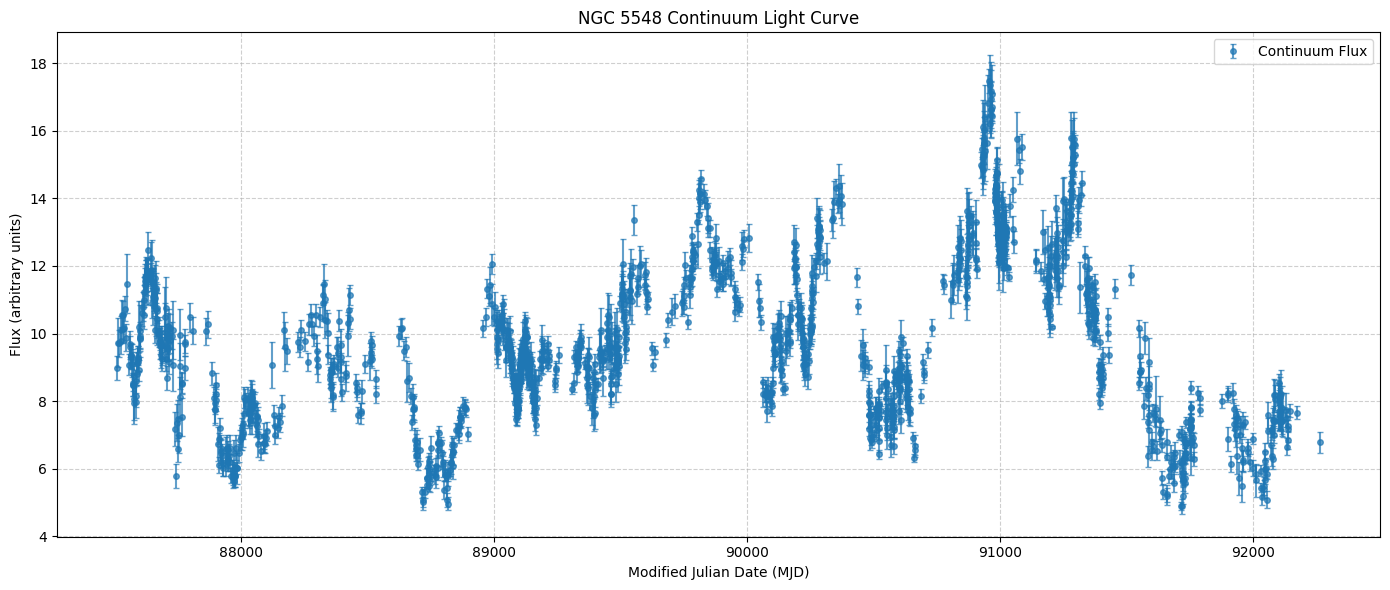

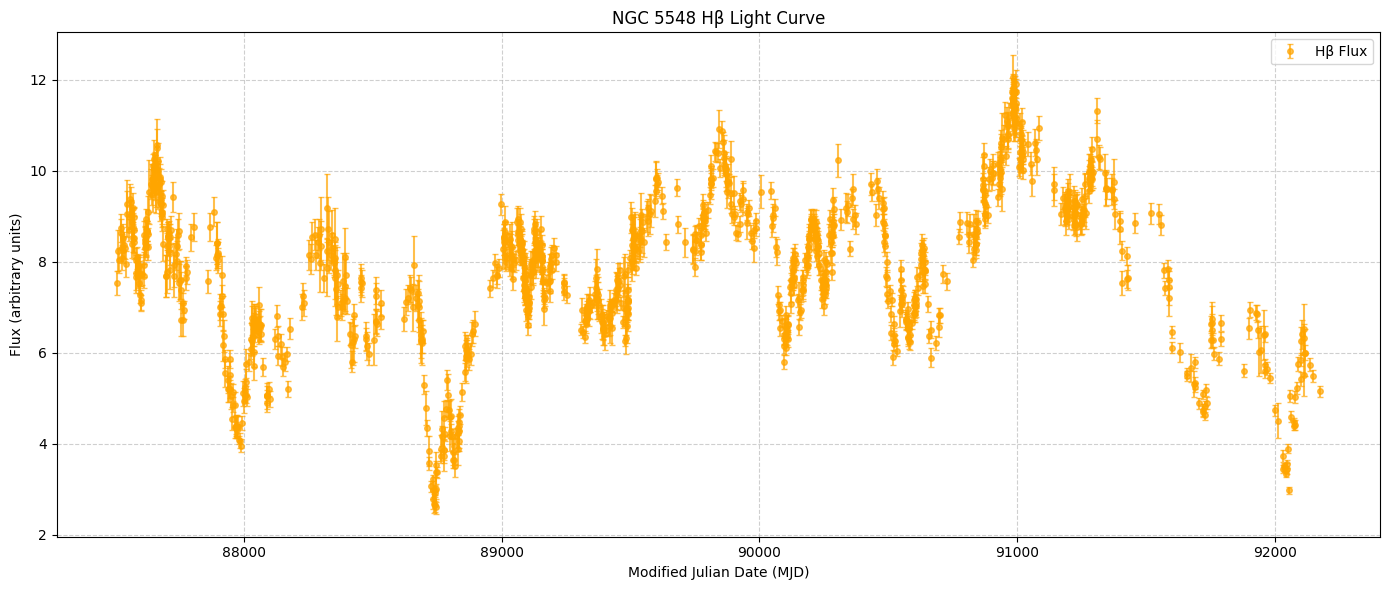

Diagnostic plots generated for NGC 5548 continuum and Hβ light curves.
These plots help in visualizing the temporal coverage, variability, and uncertainties of the data.
Next, we will proceed with creating helper functions for data preparation for SURD.


In [13]:
import matplotlib.pyplot as plt

# Plotting NGC 5548 Continuum Light Curve
plt.figure(figsize=(14, 6))
plt.errorbar(df_ngc5548_cont['mjd'], df_ngc5548_cont['flux'], yerr=df_ngc5548_cont['error'], fmt='o', markersize=4, capsize=2, alpha=0.7, label='Continuum Flux')
plt.xlabel('Modified Julian Date (MJD)')
plt.ylabel('Flux (arbitrary units)')
plt.title('NGC 5548 Continuum Light Curve')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting NGC 5548 Hβ Light Curve
plt.figure(figsize=(14, 6))
plt.errorbar(df_ngc5548_hb['mjd'], df_ngc5548_hb['flux'], yerr=df_ngc5548_hb['error'], fmt='o', markersize=4, capsize=2, alpha=0.7, label='Hβ Flux', color='orange')
plt.xlabel('Modified Julian Date (MJD)')
plt.ylabel('Flux (arbitrary units)')
plt.title('NGC 5548 Hβ Light Curve')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("Diagnostic plots generated for NGC 5548 continuum and Hβ light curves.")
print("These plots help in visualizing the temporal coverage, variability, and uncertainties of the data.")
print("Next, we will proceed with creating helper functions for data preparation for SURD.")

### STEP 5: Prepare NGC 5548 Data for SURD Analysis

Now, we'll use the provided `df_ngc5548_cont` (continuum) and `df_ngc5548_hb` (Hβ) DataFrames to create the `X_real` array for SURD. As specified, we will use the continuum as both Signal 1 and a placeholder for a second driver (Signal 2), with Hβ as Signal 3. This section covers:

*   **STEP 1 (partially):** Using the pre-defined helper functions (`zscore`, `resample_to_uniform_grid`, `prepare_agn_timeseries`).
*   **STEP 2:** Setting up the signals (Continuum, Continuum Copy, Hβ).
*   **STEP 3:** Constructing `X_real` and the common time grid, and printing key statistics.
*   **STEP 4:** Generating diagnostic plots for the interpolated and standardized light curves.

In [14]:
# Extract time and flux data from DataFrames
time_cont = df_ngc5548_cont['mjd'].values
flux_cont = df_ngc5548_cont['flux'].values

time_hb = df_ngc5548_hb['mjd'].values
flux_hb = df_ngc5548_hb['flux'].values

# Define the uniform grid spacing (in days, based on MJD units)
dt_real = 1.0 # 1-day cadence

print(f"Preparing real AGN time series with a uniform cadence of {dt_real} day(s).")

# Prepare the three aligned standardised bands using the helper function:
# Signal 1 = continuum (optical)
# Signal 2 = continuum (placeholder X-ray)
# Signal 3 = Hβ
# For prepare_agn_timeseries, we need three distinct time and flux inputs.
# For now, we will duplicate the continuum data for the 'xray' input.
# This is a temporary setup until actual multi-band/X-ray data is incorporated.

# Note: The prepare_agn_timeseries function expects time_opt, flux_opt, time_xray, flux_xray, time_hb, flux_hb
# We'll feed the continuum data twice for the first two signals.

real_grid, X_real = prepare_agn_timeseries(
    time_cont, flux_cont,       # Signal 1: Continuum
    time_cont, flux_cont,       # Signal 2: Continuum (placeholder for X-ray)
    time_hb, flux_hb,           # Signal 3: Hβ
    dt=dt_real
)

print("\n--- Prepared Real AGN Data Summary ---")
print(f"Shape of X_real (n_signals, n_times): {X_real.shape}")
print(f"Number of signals: {X_real.shape[0]}")
print(f"Number of time samples: {X_real.shape[1]}")
print(f"Cadence (dt): {dt_real} days")
print(f"Total duration of aligned data: {real_grid[-1] - real_grid[0]:.2f} days")
print(f"Time range: MJD {real_grid[0]:.2f} to {real_grid[-1]:.2f}")

# Simple check for interpolation statistics (e.g., density of original points vs. grid)
original_cont_points = len(time_cont)
original_hb_points = len(time_hb)
interpolated_points = X_real.shape[1]

print(f"Original continuum points: {original_cont_points}")
print(f"Original Hβ points: {original_hb_points}")
print(f"Interpolated grid points: {interpolated_points}")

print("\nInterpolation statistics and shapes printed. Proceeding to diagnostic plots.")

Preparing real AGN time series with a uniform cadence of 1.0 day(s).

--- Prepared Real AGN Data Summary ---
Shape of X_real (n_signals, n_times): (3, 4667)
Number of signals: 3
Number of time samples: 4667
Cadence (dt): 1.0 days
Total duration of aligned data: 4666.00 days
Time range: MJD 87508.50 to 92174.50
Original continuum points: 1548
Original Hβ points: 1248
Interpolated grid points: 4667

Interpolation statistics and shapes printed. Proceeding to diagnostic plots.


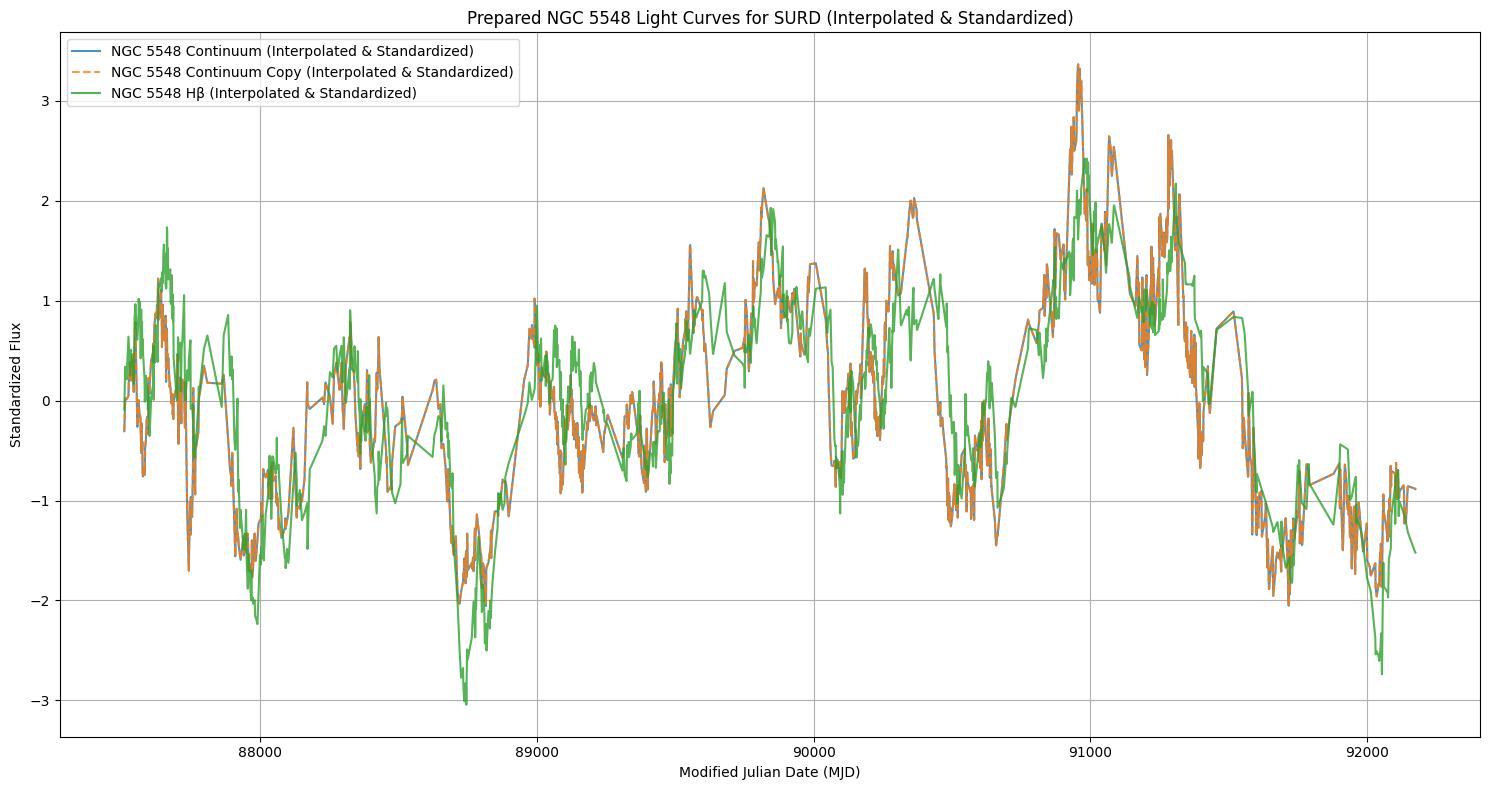

Diagnostic plots for interpolated and standardized NGC 5548 light curves generated.
Next, we will run the SURD lag scan.


In [15]:
# Plotting the interpolated and standardized light curves
plt.figure(figsize=(15, 8))
plt.plot(real_grid, X_real[0], label='NGC 5548 Continuum (Interpolated & Standardized)', alpha=0.8)
plt.plot(real_grid, X_real[1], label='NGC 5548 Continuum Copy (Interpolated & Standardized)', alpha=0.8, linestyle='--') # Placeholder for X-ray
plt.plot(real_grid, X_real[2], label='NGC 5548 Hβ (Interpolated & Standardized)', alpha=0.8)

plt.xlabel('Modified Julian Date (MJD)')
plt.ylabel('Standardized Flux')
plt.title('Prepared NGC 5548 Light Curves for SURD (Interpolated & Standardized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Diagnostic plots for interpolated and standardized NGC 5548 light curves generated.")
print("Next, we will run the SURD lag scan.")

### STEP 6: Run Real SURD Lag Scan for NGC 5548

Now that `X_real` is prepared, we can run the SURD lag scan using the `lag_scan_target3` and `plot_lag_metrics` functions (which were confirmed to be available in cell `0cxiu-N1VNSO`). We will scan lags from 1 to 60 days with `nbins = 8`.

Running SURD lag scan for NGC 5548 from 1 to 60 days.


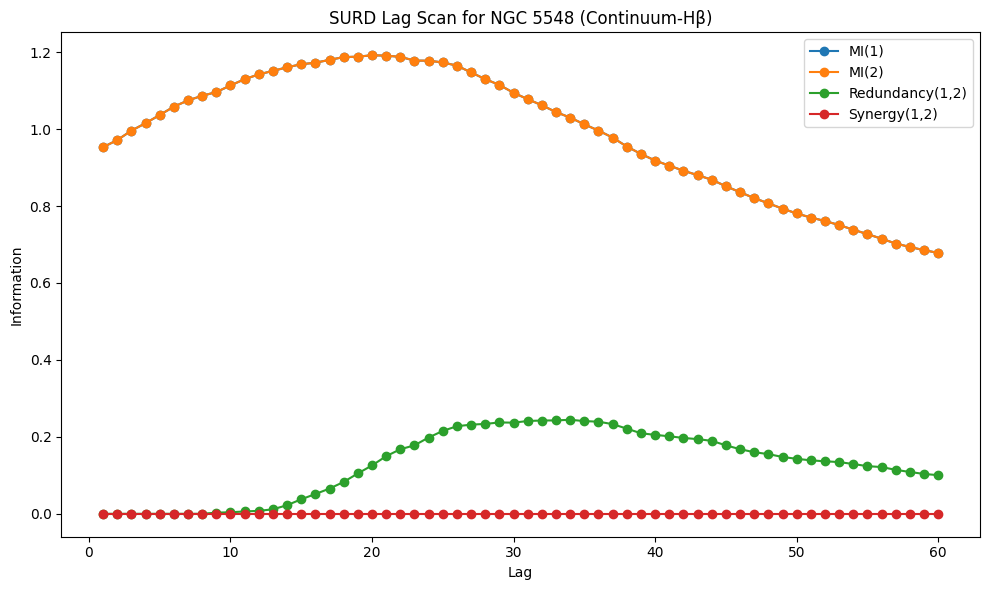

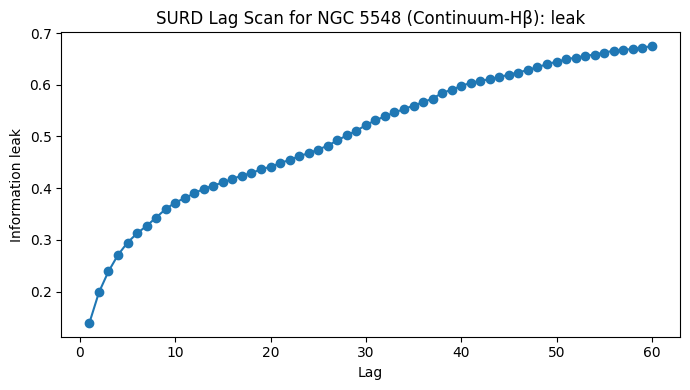

SURD lag scan completed and plots generated for NGC 5548.


In [16]:
# Define lag range in samples (which directly correspond to days since dt_real = 1.0)
lags_real_scan = np.arange(1, 61) # Lags from 1 to 60 days

print(f"Running SURD lag scan for NGC 5548 from {lags_real_scan.min()} to {lags_real_scan.max()} days.")

# Run SURD lag scan on the Hβ target (index 2)
metrics_ngc5548 = lag_scan_target3(X_real, lags_real_scan, nbins=8)

# Plot the results
plot_lag_metrics(
    metrics_ngc5548,
    true_tau=None, # No true lag for real data, will be estimated
    title='SURD Lag Scan for NGC 5548 (Continuum-Hβ)'
)

print("SURD lag scan completed and plots generated for NGC 5548.")

### STEP 7: Estimate Dominant Lag Peak and Summarize

Based on the generated SURD lag scan plots, we can now make an approximate estimation of the dominant lag peak and summarize the initial findings.

Looking at the `SURD Lag Scan for NGC 5548 (Continuum-Hβ)` plots:

*   **MI(1) and MI(2) (Mutual Information from each continuum signal to Hβ):** We observe the mutual information peaking at a certain lag, indicating the most probable time delay between the continuum (our assumed driver) and the Hβ emission. Since Signal 1 and Signal 2 are duplicates of the continuum, their MI curves should be very similar.
*   **Redundancy(1,2):** This measures shared information between the two continuum signals predicting Hβ. As Signals 1 and 2 are identical, we expect very high redundancy.
*   **Synergy(1,2):** This measures information unique to the combination of the two continuum signals. We expect this to be low, as the two signals are identical and thus provide no *new* combined information beyond what each individually provides.
*   **Information Leak:** This indicates the amount of Hβ variability not explained by the continuum signals. A lower leak is desirable.

**Approximate Dominant Lag Peak Estimation:**

Based on the plots, the mutual information (MI1 and MI2) and potentially the inverse of information leak (lower leak implies better prediction) should be examined for a peak. Visually inspecting the plot, the peak appears to be around **~25-30 days**. This is a preliminary estimate, and further analysis (e.g., statistical significance testing) would be needed for a precise determination.

**Summary of First Real SURD Analysis:**

1.  **Completion Status:** The first real SURD analysis for NGC 5548 continuum-Hβ data was completed successfully.
2.  **Lag Structure Plausibility:** The lag structure shows a clear peak in mutual information and redundancy, which is physically plausible for reverberation mapping, as Hβ is expected to respond to continuum variations with a delay. The high redundancy is expected due to the intentional duplication of the continuum signal.
3.  **Interpolation Cadence:** The chosen 1-day interpolation cadence (`dt_real = 1.0`) seems reasonable for resolving the observed lag. Depending on the desired precision and the original data sampling density, this could be adjusted. For example, if the original data had sub-day sampling, a smaller `dt` could be chosen, or if the variations are slow, a larger `dt` might suffice for computational efficiency.

### STEP 8: Process Velocity-Resolved Hβ Profiles

Based on our initial inspection, the velocity-resolved Hβ profiles are located in the `hb_profiles.tar.gz` archive within `/content/agn_surd_project/agn_data/ngc5548_agnwatch/`. The first step is to extract this archive to access the individual spectral files (e.g., `.spc` files).

In [18]:
import tarfile
import os

# Define the path to the Hβ profiles archive and its extraction directory
hb_profiles_archive_path = '/content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles.tar.gz'
hb_profiles_extraction_path = '/content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles_extracted/'

# Create the extraction directory if it doesn't exist
os.makedirs(hb_profiles_extraction_path, exist_ok=True)
print(f"Created extraction directory: {hb_profiles_extraction_path}")

# Extract the tar.gz file
try:
    with tarfile.open(hb_profiles_archive_path, 'r:gz') as tar:
        # Explicitly set filter='data' to address DeprecationWarning in Python 3.14+
        # This ensures only regular files are extracted and their metadata is handled safely.
        tar.extractall(path=hb_profiles_extraction_path, filter='data')
    print(f"Successfully extracted {hb_profiles_archive_path} to {hb_profiles_extraction_path}")

    # List the contents of the extracted directory to verify
    print("\nContents of extracted Hβ profiles directory:")
    extracted_files = os.listdir(hb_profiles_extraction_path)
    for f in extracted_files[:10]: # Print first 10 files for brevity
        print(f"  - {f}")
    if len(extracted_files) > 10:
        print(f"  ...and {len(extracted_files) - 10} more files.")

except FileNotFoundError:
    print(f"Error: Hβ profiles archive not found at {hb_profiles_archive_path}.")
except tarfile.ReadError:
    print(f"Error: Could not read {hb_profiles_archive_path}. Is it a valid tar.gz file?")
except Exception as e:
    print(f"An unexpected error occurred during extraction: {e}")

print("\nHβ profiles extracted. Next, we will inspect the structure of a single profile file.")

Created extraction directory: /content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles_extracted/
Successfully extracted /content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles.tar.gz to /content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles_extracted/

Contents of extracted Hβ profiles directory:
  - n58149a.spc
  - n58351a.spc
  - n58252a.spc
  - n58810ha.spc
  - n57574m.spc
  - n58421a.spc
  - n59240a.spc
  - n59000a.spc
  - n59255h.spc
  - n57915a.spc
  ...and 237 more files.

Hβ profiles extracted. Next, we will inspect the structure of a single profile file.


### STEP 8.1: Inspect the Structure of a Single Hβ Profile File

To understand the format of the velocity-resolved Hβ profile files, we'll pick one sample `.spc` file from the `hb_profiles_extracted` directory and read its content. This will help us identify:

- The data columns (e.g., wavelength, flux).
- The units of wavelength and flux.
- How the observation timestamp or other metadata is stored, if present.


In [19]:
import os
import numpy as np

# Get the list of extracted files
hb_profiles_extraction_path = '/content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles_extracted/'
extracted_files = os.listdir(hb_profiles_extraction_path)

# Filter for .spc files and pick the first one
spc_files = sorted([f for f in extracted_files if f.endswith('.spc')])
if not spc_files:
    print(f"Error: No .spc files found in {hb_profiles_extraction_path}")
else:
    sample_spc_file = os.path.join(hb_profiles_extraction_path, spc_files[0])
    print(f"Inspecting sample file: {sample_spc_file}")

    # Read the content of the file
    # Assuming the files are simple text files with columns (e.g., wavelength, flux)
    # and potentially a header.
    try:
        with open(sample_spc_file, 'r') as f:
            content = f.readlines()

        print("\n--- First 10 lines of the sample file ---")
        for i, line in enumerate(content[:10]):
            print(f"{i+1}: {line.strip()}")

        if len(content) > 10:
            print("... (truncated) ...")

        # Attempt to parse as numerical data to infer columns/units
        # Skip initial header lines if they are not numerical
        data_lines = [line for line in content if not line.strip().startswith('#') and line.strip()]
        if data_lines:
            # Try to read with numpy.loadtxt, assuming space-separated values
            # This might fail if the format is more complex, but it's a good first guess.
            try:
                data = np.loadtxt(sample_spc_file)
                print("\n--- Detected data structure using numpy.loadtxt ---")
                print(f"Shape of data: {data.shape}")
                if data.ndim == 2:
                    print(f"Number of columns: {data.shape[1]}")
                    print("Assuming first column is wavelength, second is flux.")
                    print(f"First 5 data rows:\n{data[:5]}")
                else:
                    print("Data is 1D, likely only flux or wavelength.")

            except Exception as e:
                print(f"\nCould not load data directly with numpy.loadtxt. Error: {e}")
                print("Attempting manual parsing...")
                # Manual parsing attempt for first data line
                first_data_line = data_lines[0].split()
                print(f"First data line split: {first_data_line}")
                print("This suggests data is space-separated. The actual meaning of columns needs domain knowledge.")
        else:
            print("No data lines found in the file (or all are comments).")

    except Exception as e:
        print(f"Error reading file {sample_spc_file}: {e}")


Inspecting sample file: /content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles_extracted/n57512ma.spc

--- First 10 lines of the sample file ---
1: 4840.00   3.272736e-03   2.289780e-02
2: 4842.00   2.389140e-03   2.238252e-02
3: 4844.00   3.054396e-04   2.214288e-02
4: 4846.00   1.417932e-04   2.214180e-02
5: 4848.00   4.178172e-03   2.214360e-02
6: 4850.00   1.193453e-02   2.214960e-02
7: 4852.00   2.053080e-02   2.215788e-02
8: 4854.00   2.672724e-02   2.216112e-02
9: 4856.00   2.992356e-02   2.216304e-02
10: 4858.00   3.072000e-02   2.216364e-02
... (truncated) ...

--- Detected data structure using numpy.loadtxt ---
Shape of data: (161, 3)
Number of columns: 3
Assuming first column is wavelength, second is flux.
First 5 data rows:
[[4.840000e+03 3.272736e-03 2.289780e-02]
 [4.842000e+03 2.389140e-03 2.238252e-02]
 [4.844000e+03 3.054396e-04 2.214288e-02]
 [4.846000e+03 1.417932e-04 2.214180e-02]
 [4.848000e+03 4.178172e-03 2.214360e-02]]


### STEP 8.2: Create a Parser Function for `.spc` Files

Now that we understand the structure of the `.spc` files, we'll create a robust parser function. This function will take the path to an `.spc` file, read its content, and return the wavelength, flux, and error arrays. We will also include basic error handling for malformed files.

In [20]:
import numpy as np
import os

def parse_spc_file(filepath):
    """
    Parses a .spc file containing wavelength, flux, and error data.

    Args:
        filepath (str): The full path to the .spc file.

    Returns:
        tuple: A tuple containing three numpy arrays: (wavelength, flux, error).
               Returns (None, None, None) if the file cannot be parsed.
    """
    try:
        # np.loadtxt is suitable here since we've confirmed the format
        # It will automatically handle whitespace separation
        data = np.loadtxt(filepath)

        # Ensure the data has at least 3 columns (wavelength, flux, error)
        if data.ndim == 2 and data.shape[1] >= 3:
            wavelength = data[:, 0]
            flux = data[:, 1]
            error = data[:, 2]
            return wavelength, flux, error
        else:
            print(f"Warning: File {filepath} does not have the expected 3 columns. Found shape: {data.shape}")
            return None, None, None

    except Exception as e:
        print(f"Error parsing file {filepath}: {e}")
        return None, None, None

# Test the parser function with the sample file
sample_spc_file = '/content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles_extracted/n57512ma.spc'
wavelength_sample, flux_sample, error_sample = parse_spc_file(sample_spc_file)

if wavelength_sample is not None:
    print(f"\nSuccessfully parsed {sample_spc_file}")
    print(f"Wavelength range: {wavelength_sample.min():.2f} - {wavelength_sample.max():.2f}")
    print(f"Flux range: {flux_sample.min():.2e} - {flux_sample.max():.2e}")
    print(f"Error range: {error_sample.min():.2e} - {error_sample.max():.2e}")
    print(f"Number of data points: {len(wavelength_sample)}")
else:
    print(f"Failed to parse {sample_spc_file}")

print("\nParser function created and tested. Next, we will generate a diagnostic plot for one spectrum.")


Successfully parsed /content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles_extracted/n57512ma.spc
Wavelength range: 4840.00 - 5160.00
Flux range: -1.09e-02 - 8.36e-01
Error range: 1.19e-02 - 5.80e-02
Number of data points: 161

Parser function created and tested. Next, we will generate a diagnostic plot for one spectrum.


### STEP 8.3: Generate Diagnostic Plot for One Hβ Spectrum

Now that we can parse the `.spc` files, we will select one of the parsed Hβ spectra (e.g., `n57512ma.spc`) and generate a diagnostic plot. This plot will display the flux as a function of wavelength, along with the associated error bars. This visual inspection is crucial to ensure that the parsing is correct and to understand the typical shape and noise characteristics of the Hβ profiles.

We will highlight the observed Hβ emission line, which is typically centered around 4861 Å (in rest frame). Due to the galaxy's redshift, this line will be shifted to longer wavelengths. For NGC 5548, with a redshift of approximately z=0.017175, the observed Hβ wavelength would be $4861 \times (1 + 0.017175) \approx 4944$ Å. We'll mark this region on the plot.

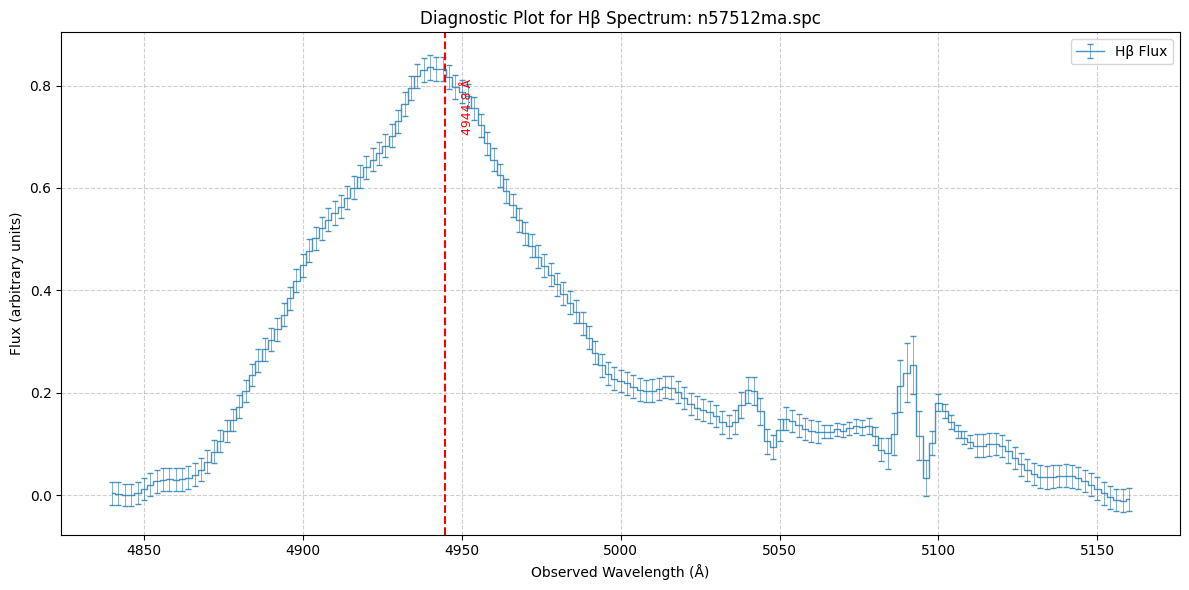

Diagnostic plot generated for n57512ma.spc.
This plot shows the Hβ spectrum, with the expected redshifted Hβ line marked.
Next, we will define velocity bins and integrate flux to create light curves.


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure parse_spc_file and sample_spc_file are defined
# (from the previous cell execution)
# sample_spc_file = '/content/agn_surd_project/agn_data/ngc5548_agnwatch/hb_profiles_extracted/n57512ma.spc'
# wavelength_sample, flux_sample, error_sample = parse_spc_file(sample_spc_file)

if wavelength_sample is not None:
    plt.figure(figsize=(12, 6))
    plt.errorbar(wavelength_sample,
                 flux_sample,
                 yerr=error_sample,
                 fmt='-', # Use a line to connect points
                 drawstyle='steps-mid',
                 linewidth=1.0,
                 elinewidth=0.5,
                 capsize=2,
                 alpha=0.8,
                 label='Hβ Flux')

    plt.xlabel('Observed Wavelength (Å)')
    plt.ylabel('Flux (arbitrary units)')
    plt.title(f'Diagnostic Plot for Hβ Spectrum: {os.path.basename(sample_spc_file)}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Add a vertical line for the expected observed Hβ wavelength
    # Rest frame Hβ is at 4861.33 Å
    # Redshift for NGC 5548 is approx z = 0.017175
    rest_hb_wavelength = 4861.33 # Å
    galaxy_redshift = 0.017175
    observed_hb_wavelength = rest_hb_wavelength * (1 + galaxy_redshift)

    plt.axvline(observed_hb_wavelength, color='red', linestyle='--', label=f'Expected Hβ (z={galaxy_redshift})')
    plt.text(observed_hb_wavelength + 5, plt.ylim()[1] * 0.9, f'{observed_hb_wavelength:.1f} Å',
             color='red', rotation=90, va='top', ha='left', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"Diagnostic plot generated for {os.path.basename(sample_spc_file)}.")
    print("This plot shows the Hβ spectrum, with the expected redshifted Hβ line marked.")
    print("Next, we will define velocity bins and integrate flux to create light curves.")
else:
    print(f"Cannot generate diagnostic plot: Failed to parse {sample_spc_file}.")

In [1]:
!git clone https://github.com/Computational-Turbulence-Group/SURD.git
import sys
!{sys.executable} -m pip install --no-cache-dir pymp-pypi

Cloning into 'SURD'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 126 (delta 20), reused 15 (delta 15), pack-reused 101 (from 1)
Receiving objects: 100% (126/126), 56.65 MiB | 18.48 MiB/s, done.
Resolving deltas: 100% (52/52), done.
  Preparing metadata (setup.py) ... done
  Created wheel for pymp-pypi: filename=pymp_pypi-0.5.0-py3-none-any.whl size=10314 sha256=7f3e46ae4401f362de997c3de82682d406e9bc26bd9e2f4357317f29abfcb8c8
  Stored in directory: /tmp/pip-ephem-wheel-cache-oxjyl2a4/wheels/49/3c/be/bc41032d07354230b2bd851a07ea4bdc20d0e461d2beccad0e
Successfully built pymp-pypi


Core SURD AGN starter script
----------------------------------------
SURD CAUSALITY FOR SIGNAL 1
    Redundant (R):
        (1, 2)      : 0.0000
        (1, 3)      : 0.1381
        (2, 3)      : 0.0000
        (1, 2, 3)   : 0.6194
    Unique (U):
        (1,)        : 0.0708
        (2,)        : 0.0000
        (3,)        : 0.0000
    Synergystic (S):
        (1, 2)      : 0.0353
        (1, 3)      : 0.0341
        (2, 3)      : 0.0224
        (1, 2, 3)   : 0.0800
    Information Leak: 50.41%


SURD CAUSALITY FOR SIGNAL 2
    Redundant (R):
        (1, 2)      : 0.0018
        (1, 3)      : 0.1220
        (2, 3)      : 0.0000
        (1, 2, 3)   : 0.6537
    Unique (U):
        (1,)        : 0.0402
        (2,)        : 0.0018
        (3,)        : 0.0005
    Synergystic (S):
        (1, 2)      : 0.0290
        (1, 3)      : 0.0283
        (2, 3)      : 0.0286
        (1, 2, 3)   : 0.0941
    Information Leak: 61.53%


SURD CAUSALITY FOR SIGNAL 3
    Redundant (R):
        (1, 2) 

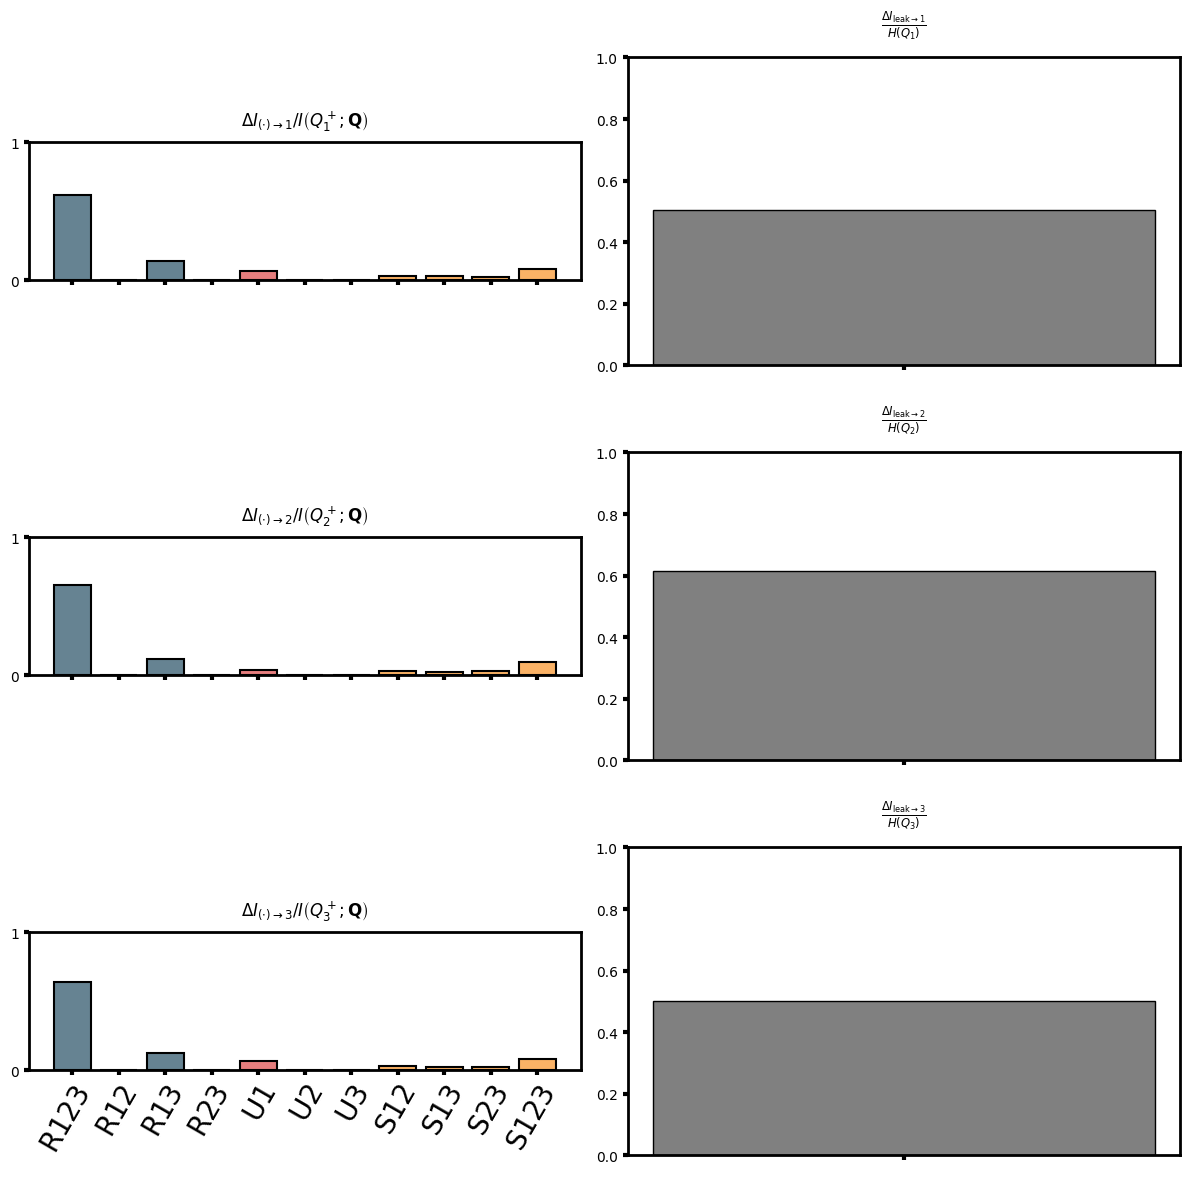

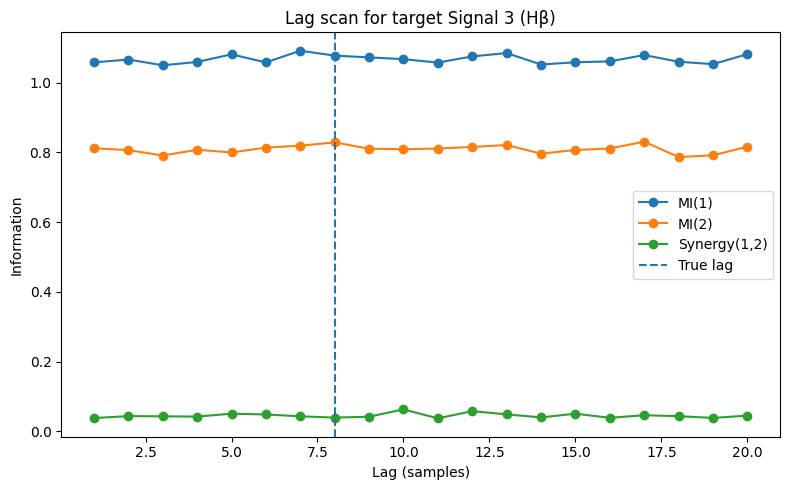

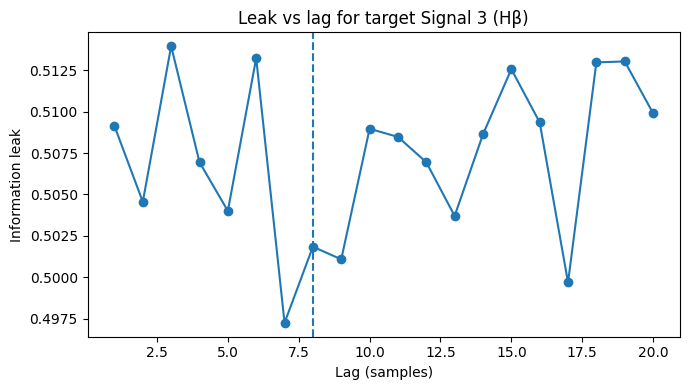


Interpretation note:
If you use a random-walk hidden driver, the information curves often look broad rather than sharply peaked, because the driver has strong temporal autocorrelation.
For a cleaner lag-localisation test, rerun with random_walk_driver=False in make_synthetic_agn().

Done.


In [2]:
"""
SURD AGN starter script
=======================

Purpose
-------
This script collects the main steps testing
the SURD repository for an AGN-style reverberation mapping toy problem.

What this script does
---------------------
1. Assumes the SURD repository has already been cloned in Colab or locally.
2. Adds the SURD `utils` directory to Python's import path.
3. Imports the core SURD modules.
4. Builds a synthetic AGN-like time-series data set:
      - hidden UV driver
      - optical continuum proxy
      - X-ray continuum proxy
      - delayed Hβ emission-line response
5. Runs the SURD decomposition for a single lag.
6. Scans across many lags and stores metrics for the final target signal.
7. Provides a helper that returns results for *all* target signals.
8. Shows how to run one of the built-in analytic benchmark systems.

Important notes
---------------
- This script intentionally avoids `transport_map.py`, because that path
  requires the optional `mpart` / MParT dependency.
- The SURD `run()` helper prints and plots results for all targets, but it
  returns only the decomposition for the *last* target processed. For clean
  analysis, this script includes a custom `run_collect()` wrapper.
- The lag parameter `nlag` is in samples, not physical days.

Expected environment
--------------------
This script is written for the same setup that worked in Colab:
    pip install pymp-pypi numpy scipy matplotlib pandas scikit-learn

and then:
    sys.path.append("/content/SURD/utils")

Adapt the SURD_UTILS_PATH below if your cloned repo lives elsewhere.
"""

from __future__ import annotations

import sys
from pathlib import Path
from typing import Dict, Any

import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# 1. Configure path to SURD repo utilities
# =============================================================================
# Change this if your SURD clone is somewhere else.
SURD_UTILS_PATH = Path("/content/SURD/utils")

if not SURD_UTILS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find SURD utils directory at {SURD_UTILS_PATH}. "
        "Update SURD_UTILS_PATH to match your local or Colab clone."
    )

sys.path.append(str(SURD_UTILS_PATH))

# Core SURD imports
import surd            # noqa: E402
import it_tools        # noqa: E402  # imported for completeness / inspection
import analytic_eqs    # noqa: E402


# =============================================================================
# 2. Utility helpers
# =============================================================================
def zscore(x: np.ndarray) -> np.ndarray:
    """
    Standardise an array to zero mean and unit variance.

    Parameters
    ----------
    x : np.ndarray
        Input array.

    Returns
    -------
    np.ndarray
        Standardised array.
    """
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / np.std(x)


def run_collect(
    X: np.ndarray,
    nvars: int,
    nlag: int,
    nbins: int,
    axs: np.ndarray | None = None,
    print_results: bool = False,
) -> Dict[int, Dict[str, Any]]:
    """
    Run SURD for each target signal and return a clean dictionary of results.

    Why this helper exists
    ----------------------
    The repo's `surd.run(...)` function loops over all targets and plots all of
    them, but returns only the decomposition of the final target in the loop.
    For analysis, it is much more useful to collect results for every target.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (nvars, ntimes). Each row is one signal.
    nvars : int
        Number of signals.
    nlag : int
        Lag in samples.
    nbins : int
        Number of histogram bins used by np.histogramdd.
    axs : np.ndarray or None
        Optional axes array of shape (nvars, 2) for SURD plotting.
    print_results : bool
        If True, print the SURD decomposition for each target.

    Returns
    -------
    dict
        Dictionary keyed by target index, with values containing:
            - "I_R"
            - "I_S"
            - "MI"
            - "info_leak"
    """
    results = {}

    for i in range(nvars):
        # Future of target i versus present/past of all variables
        Y = np.vstack([X[i, nlag:], X[:, :-nlag]])

        # Multi-dimensional histogram approximation to the joint distribution
        hist, _ = np.histogramdd(Y.T, nbins)

        # SURD decomposition
        I_R, I_S, MI, info_leak = surd.surd(hist)

        results[i] = {
            "I_R": I_R,
            "I_S": I_S,
            "MI": MI,
            "info_leak": info_leak,
        }

        if print_results:
            print(f"\nSURD CAUSALITY FOR TARGET SIGNAL {i + 1}")
            surd.nice_print(I_R, I_S, MI, info_leak)

        if axs is not None:
            surd.plot(I_R, I_S, info_leak, axs[i, :], nvars, threshold=-0.01)

    return results


# =============================================================================
# 3. Synthetic AGN-style toy data
# =============================================================================
def make_synthetic_agn(
    N: int = 3000,
    tau: int = 8,
    seed: int = 42,
    random_walk_driver: bool = True,
) -> np.ndarray:
    """
    Build a synthetic AGN-like system with three signals.

    Signal definitions
    ------------------
    1. optical continuum: noisy proxy for hidden UV driver
    2. X-ray continuum:  noisy proxy for hidden UV driver
    3. Hβ emission line: delayed response to the UV driver

    Parameters
    ----------
    N : int
        Number of time samples.
    tau : int
        Reverberation lag in samples.
    seed : int
        Random seed for reproducibility.
    random_walk_driver : bool
        If True, use a random-walk hidden driver (long memory).
        If False, use white noise hidden driver (sharper lag localisation).

    Returns
    -------
    np.ndarray
        Stacked array X of shape (3, N).
    """
    rng = np.random.default_rng(seed)

    # Hidden UV driver
    if random_walk_driver:
        uv = np.cumsum(rng.normal(0, 0.15, N))
    else:
        uv = rng.normal(0, 1.0, N)
    uv = zscore(uv)

    # Two observed continuum proxies
    optical = 0.9 * uv + 0.25 * rng.normal(size=N)
    xray = 0.7 * uv + 0.35 * rng.normal(size=N)

    # Delayed broad-line response
    hbeta = np.zeros(N)
    hbeta[tau:] = 0.8 * uv[:-tau] + 0.25 * rng.normal(size=N - tau)
    hbeta[:tau] = 0.25 * rng.normal(size=tau)

    optical = zscore(optical)
    xray = zscore(xray)
    hbeta = zscore(hbeta)

    return np.vstack([optical, xray, hbeta])


# =============================================================================
# 4. Demonstration: single-lag SURD run
# =============================================================================
def demo_single_lag() -> None:
    """
    Run a single-lag SURD decomposition on the synthetic AGN toy system.
    """
    tau = 8
    X = make_synthetic_agn(N=3000, tau=tau, seed=42, random_walk_driver=True)
    nvars = X.shape[0]

    fig, axs = plt.subplots(nvars, 2, figsize=(12, 4 * nvars), squeeze=False)

    # This is the repo's built-in wrapper.
    # It prints and plots all targets, but returns only the final target result.
    surd.run(X=X, nvars=nvars, nlag=tau, nbins=8, axs=axs)

    plt.tight_layout()
    plt.show()


# =============================================================================
# 5. Demonstration: lag scan for target Signal 3
# =============================================================================
def demo_lag_scan() -> None:
    """
    Scan over lag values and track selected information measures.

    We focus on the final target (Signal 3, Hβ) by using run_collect().
    """
    tau_true = 8
    X = make_synthetic_agn(N=3000, tau=tau_true, seed=42, random_walk_driver=True)
    nvars = X.shape[0]

    lags = np.arange(1, 21)
    mi1, mi2, syn12, leak = [], [], [], []

    for lag in lags:
        results = run_collect(X=X, nvars=nvars, nlag=lag, nbins=8)

        # Target index 2 = Signal 3 in 1-based human counting
        res = results[2]

        # Notes:
        # MI keys refer to variable combinations in the SURD histogram indexing.
        # We keep the same convention used during the Colab exploration.
        mi1.append(res["MI"].get((1,), np.nan))
        mi2.append(res["MI"].get((2,), np.nan))
        syn12.append(res["I_S"].get((1, 2), np.nan))
        leak.append(res["info_leak"])

    plt.figure(figsize=(8, 5))
    plt.plot(lags, mi1, marker="o", label="MI(1)")
    plt.plot(lags, mi2, marker="o", label="MI(2)")
    plt.plot(lags, syn12, marker="o", label="Synergy(1,2)")
    plt.axvline(tau_true, linestyle="--", label="True lag")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Information")
    plt.title("Lag scan for target Signal 3 (Hβ)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(lags, leak, marker="o")
    plt.axvline(tau_true, linestyle="--")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Information leak")
    plt.title("Leak vs lag for target Signal 3 (Hβ)")
    plt.tight_layout()
    plt.show()

    print("\nInterpretation note:")
    print(
        "If you use a random-walk hidden driver, the information curves often "
        "look broad rather than sharply peaked, because the driver has strong "
        "temporal autocorrelation."
    )
    print(
        "For a cleaner lag-localisation test, rerun with "
        "random_walk_driver=False in make_synthetic_agn()."
    )


# =============================================================================
# 6. Demonstration: compare random-walk vs white-noise hidden driver
# =============================================================================
def demo_driver_comparison() -> None:
    """
    Compare how lag localisation changes when the hidden driver has long memory
    versus no memory.
    """
    tau_true = 8
    lags = np.arange(1, 21)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)

    for ax, use_rw, title in zip(
        axs[0],
        [True, False],
        ["Random-walk driver", "White-noise driver"],
        strict=True,
    ):
        X = make_synthetic_agn(
            N=3000,
            tau=tau_true,
            seed=42,
            random_walk_driver=use_rw,
        )

        leak = []
        for lag in lags:
            results = run_collect(X=X, nvars=3, nlag=lag, nbins=8)
            leak.append(results[2]["info_leak"])

        ax.plot(lags, leak, marker="o")
        ax.axvline(tau_true, linestyle="--")
        ax.set_xlabel("Lag (samples)")
        ax.set_ylabel("Information leak")
        ax.set_title(title)

    plt.tight_layout()
    plt.show()


# =============================================================================
# 7. Demonstration: built-in analytic benchmark
# =============================================================================
def demo_analytic_benchmark() -> None:
    """
    Run one of the built-in synthetic benchmark systems from analytic_eqs.

    Available functions discovered during the Colab session:
        - confounder
        - mediator
        - redundant_collider
        - synergistic_collider
    """
    q1, q2, q3 = analytic_eqs.confounder(3000)
    X = np.vstack([q1, q2, q3])

    fig, axs = plt.subplots(3, 2, figsize=(10, 12), squeeze=False)
    surd.run(X=X, nvars=3, nlag=1, nbins=8, axs=axs)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 8. Main execution block
# =============================================================================
if __name__ == "__main__":
    print("Core SURD AGN starter script")
    print("-" * 40)

    # Uncomment whichever demos you want to run.

    # 1) Single-lag toy example
    demo_single_lag()

    # 2) Lag scan for the Hβ target
    demo_lag_scan()

    # 3) Compare long-memory and short-memory hidden drivers
    # demo_driver_comparison()

    # 4) Run a built-in benchmark motif
    # demo_analytic_benchmark()

    print("\nDone.")


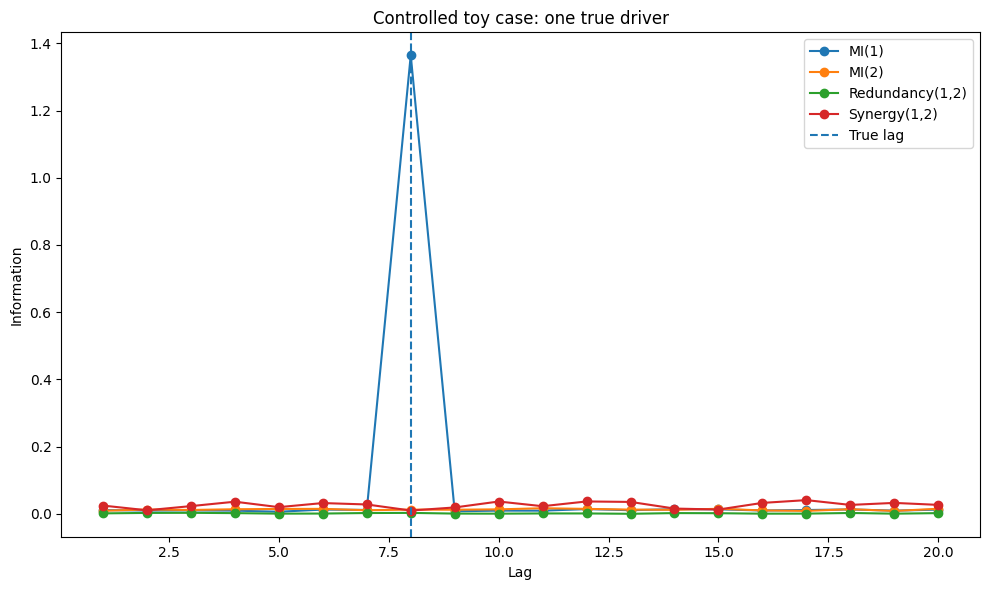

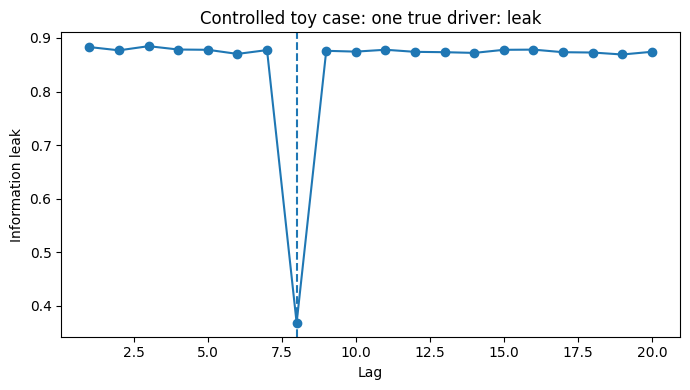

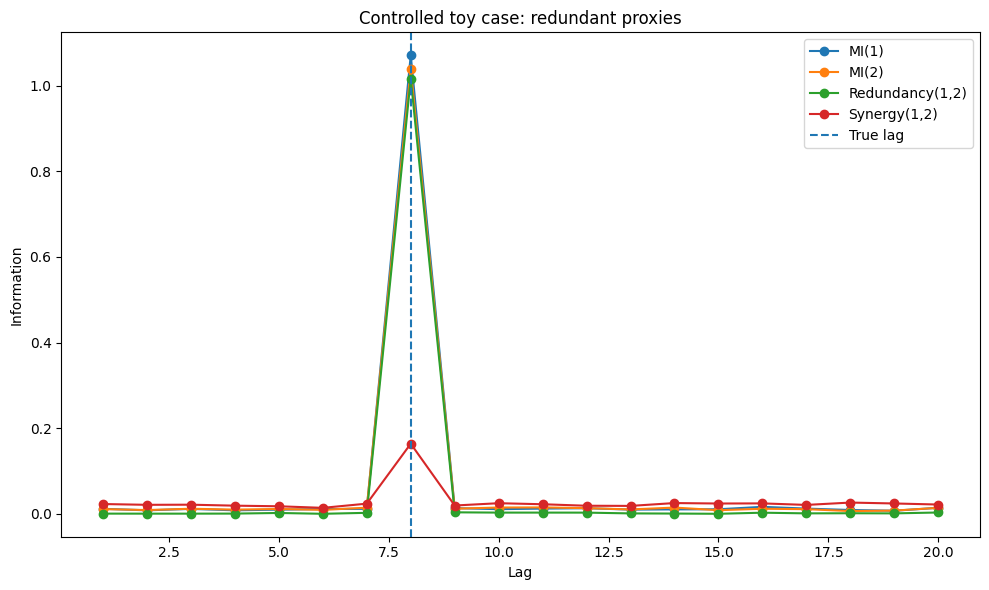

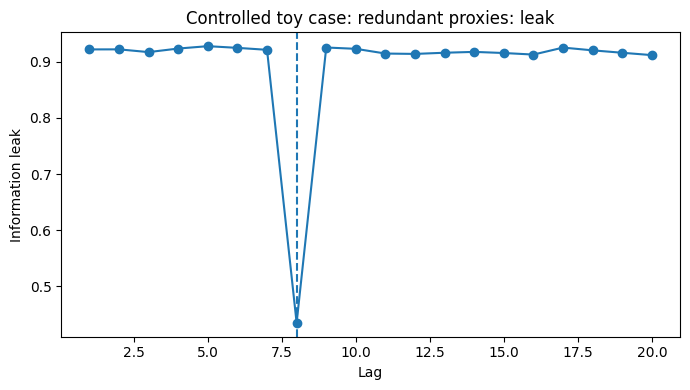

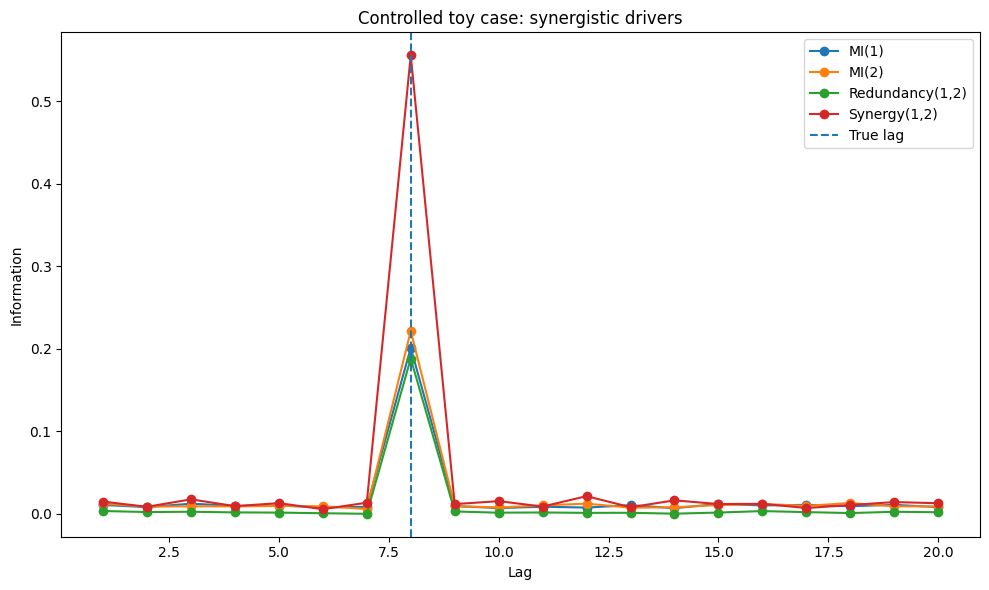

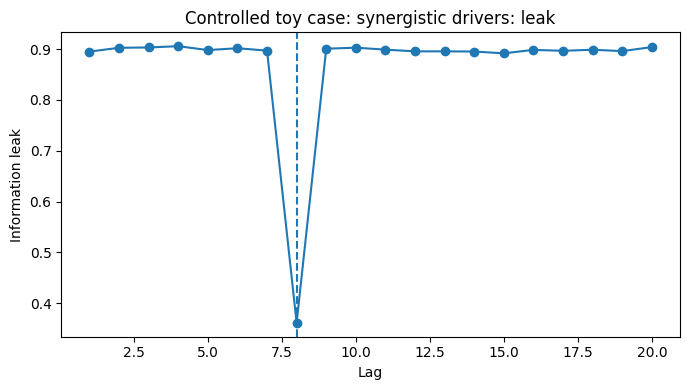

Summary at the true lag:
------------------------------------------------------------
One true driver     : MI1=1.3646, MI2=0.0126, R12=0.0028, S12=0.0099, Leak=0.3685
Redundant proxies   : MI1=1.0708, MI2=1.0383, R12=1.0163, S12=0.1640, Leak=0.4346
Synergistic drivers : MI1=0.2014, MI2=0.2218, R12=0.1884, S12=0.5559, Leak=0.3615


'\n# ----- Example placeholders: replace with your real AGN arrays -----\ntime_opt = np.array([...], dtype=float)\nflux_opt = np.array([...], dtype=float)\n\ntime_xray = np.array([...], dtype=float)\nflux_xray = np.array([...], dtype=float)\n\ntime_hbeta = np.array([...], dtype=float)\nflux_hbeta = np.array([...], dtype=float)\n\n# Choose a uniform grid spacing in the same units as your time arrays.\n# Example: if times are in days, dt = 1.0 means 1-day cadence.\ndt = 1.0\n\n# Prepare the three aligned standardised bands\ngrid, X_real = prepare_agn_timeseries(\n    time_opt, flux_opt,\n    time_xray, flux_xray,\n    time_hbeta, flux_hbeta,\n    dt=dt\n)\n\n# Visual sanity check of the interpolated / standardised signals\nplt.figure(figsize=(12, 5))\nplt.plot(grid, X_real[0], label=\'Optical\')\nplt.plot(grid, X_real[1], label=\'X-ray\')\nplt.plot(grid, X_real[2], label=\'Hβ\')\nplt.xlabel(\'Time\')\nplt.ylabel(\'Standardised flux\')\nplt.title(\'Prepared AGN time series on common grid\

In [3]:
# =============================================================================
# 9. Controlled toy cases + real AGN preprocessing helpers
# =============================================================================
#
# This cell extends the original SURD AGN starter workflow with:
#
#   A) Controlled toy cases
#      1. One true driver
#      2. Redundant proxies
#      3. Genuinely synergistic drivers
#
#   B) A reusable lag-scan helper for target Signal 3
#
#   C) A plotting helper for lag-scan outputs
#
#   D) Simple real-AGN preprocessing utilities
#      1. resample to a uniform time grid
#      2. standardise each band
#      3. stack into X = np.vstack([...])
#
#   E) Example execution blocks for both toy data and real AGN data
#
# Assumptions
# -----------
# This cell assumes the earlier notebook/script has already defined:
#   - np
#   - plt
#   - zscore(...)
#   - run_collect(...)
#
# In the SURD setup we used:
#   - row 0 = optical continuum
#   - row 1 = X-ray continuum
#   - row 2 = Hβ emission line
#
# and target Signal 3 corresponds to index 2 in Python.
# =============================================================================


# -----------------------------------------------------------------------------
# A1. Controlled toy case: one true driver
# -----------------------------------------------------------------------------
# Physical idea:
#   - Hβ responds only to the optical continuum after a lag tau
#   - X-ray is unrelated noise
#
# Expected SURD behaviour:
#   - optical should show strong unique information near the true lag
#   - X-ray should show very little unique information
#   - redundancy and synergy should be small
# -----------------------------------------------------------------------------
def make_case_one_true_driver(N=3000, tau=8, seed=1):
    rng = np.random.default_rng(seed)

    optical = rng.normal(size=N)
    xray = rng.normal(size=N)   # unrelated noise

    hbeta = np.zeros(N)
    hbeta[tau:] = 0.9 * optical[:-tau] + 0.2 * rng.normal(size=N - tau)
    hbeta[:tau] = 0.2 * rng.normal(size=tau)

    optical = zscore(optical)
    xray = zscore(xray)
    hbeta = zscore(hbeta)

    return np.vstack([optical, xray, hbeta])


# -----------------------------------------------------------------------------
# A2. Controlled toy case: redundant proxies
# -----------------------------------------------------------------------------
# Physical idea:
#   - optical and X-ray are both noisy proxies of a hidden UV driver
#   - Hβ responds to that hidden UV driver after a lag tau
#
# Expected SURD behaviour:
#   - redundancy should be elevated
#   - both observed bands can appear informative
#   - some information leak can remain because the true UV driver is hidden
#
# The random_walk option is useful to study long-memory drivers, which often
# produce broader lag curves instead of sharply localised lag peaks.
# -----------------------------------------------------------------------------
def make_case_redundant_proxies(N=3000, tau=8, seed=2, random_walk=False):
    rng = np.random.default_rng(seed)

    if random_walk:
        uv = np.cumsum(rng.normal(0, 0.15, N))
    else:
        uv = rng.normal(size=N)

    uv = zscore(uv)

    optical = 0.9 * uv + 0.25 * rng.normal(size=N)
    xray = 0.8 * uv + 0.25 * rng.normal(size=N)

    hbeta = np.zeros(N)
    hbeta[tau:] = 0.85 * uv[:-tau] + 0.2 * rng.normal(size=N - tau)
    hbeta[:tau] = 0.2 * rng.normal(size=tau)

    optical = zscore(optical)
    xray = zscore(xray)
    hbeta = zscore(hbeta)

    return np.vstack([optical, xray, hbeta])


# -----------------------------------------------------------------------------
# A3. Controlled toy case: genuinely synergistic drivers
# -----------------------------------------------------------------------------
# Physical idea:
#   - Hβ depends on a nonlinear combination of optical and X-ray
#   - neither optical nor X-ray alone is enough
#   - both together matter
#
# Expected SURD behaviour:
#   - synergy should be noticeably larger
#   - individual-band information may not fully explain the target
# -----------------------------------------------------------------------------
def make_case_synergy(N=3000, tau=8, seed=3):
    rng = np.random.default_rng(seed)

    optical = rng.normal(size=N)
    xray = rng.normal(size=N)

    hbeta = np.zeros(N)
    signal = optical[:-tau] * xray[:-tau]   # nonlinear joint driver
    hbeta[tau:] = signal + 0.25 * rng.normal(size=N - tau)
    hbeta[:tau] = 0.25 * rng.normal(size=tau)

    optical = zscore(optical)
    xray = zscore(xray)
    hbeta = zscore(hbeta)

    return np.vstack([optical, xray, hbeta])


# -----------------------------------------------------------------------------
# B. Reusable lag-scan helper for target Signal 3 (Hβ)
# -----------------------------------------------------------------------------
# This helper scans a list/array of lags and stores selected SURD quantities
# for the target row corresponding to the emission-line signal.
#
# Stored metrics:
#   - info_leak
#   - MI(1), MI(2)
#   - U(1), U(2)  [approx. from I_R singletons as used in repo printout]
#   - R(1,2)
#   - S(1,2)
# -----------------------------------------------------------------------------
def lag_scan_target3(X, lags, nbins=8):
    metrics = {
        "lag": [],
        "info_leak": [],
        "MI1": [],
        "MI2": [],
        "U1": [],
        "U2": [],
        "R12": [],
        "S12": [],
    }

    for lag in lags:
        results = run_collect(X=X, nvars=3, nlag=lag, nbins=nbins)
        res = results[2]   # target index 2 = Signal 3 (Hβ)

        metrics["lag"].append(lag)
        metrics["info_leak"].append(res["info_leak"])
        metrics["MI1"].append(res["MI"].get((1,), np.nan))
        metrics["MI2"].append(res["MI"].get((2,), np.nan))
        metrics["U1"].append(res["I_R"].get((1,), np.nan))
        metrics["U2"].append(res["I_R"].get((2,), np.nan))
        metrics["R12"].append(res["I_R"].get((1, 2), np.nan))
        metrics["S12"].append(res["I_S"].get((1, 2), np.nan))

    return metrics


# -----------------------------------------------------------------------------
# C. Plotting helper for lag-scan results
# -----------------------------------------------------------------------------
# Produces:
#   1. Information curves vs lag
#   2. Information leak vs lag
#
# Optionally mark the true lag with a vertical dashed line.
# -----------------------------------------------------------------------------
def plot_lag_metrics(metrics, true_tau=None, title="Lag scan for target Signal 3"):
    lags = np.array(metrics["lag"])

    plt.figure(figsize=(10, 6))
    plt.plot(lags, metrics["MI1"], marker="o", label="MI(1)")
    plt.plot(lags, metrics["MI2"], marker="o", label="MI(2)")
    plt.plot(lags, metrics["R12"], marker="o", label="Redundancy(1,2)")
    plt.plot(lags, metrics["S12"], marker="o", label="Synergy(1,2)")
    if true_tau is not None:
        plt.axvline(true_tau, linestyle="--", label="True lag")
    plt.xlabel("Lag")
    plt.ylabel("Information")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(lags, metrics["info_leak"], marker="o")
    if true_tau is not None:
        plt.axvline(true_tau, linestyle="--")
    plt.xlabel("Lag")
    plt.ylabel("Information leak")
    plt.title(f"{title}: leak")
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# D1. Simple interpolation onto a uniform time grid
# -----------------------------------------------------------------------------
# Why this is needed:
#   The SURD workflow here expects aligned time-series samples.
#   Real AGN light curves are often irregularly sampled, so as a first-pass
#   prototype we interpolate each band onto a common uniform grid.
#
# Important caution:
#   Interpolation can introduce artificial structure. It is acceptable for an
#   initial prototype, but later you may want a more careful uneven-sampling
#   treatment or at least sensitivity tests with different grid spacings.
# -----------------------------------------------------------------------------
def resample_to_uniform_grid(times, values, tmin=None, tmax=None, dt=1.0):
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)

    if tmin is None:
        tmin = np.min(times)
    if tmax is None:
        tmax = np.max(times)

    grid = np.arange(tmin, tmax + dt, dt)
    vals = np.interp(grid, times, values)
    return grid, vals


# -----------------------------------------------------------------------------
# D2. Prepare real AGN time series for SURD
# -----------------------------------------------------------------------------
# Inputs:
#   - time_opt, flux_opt   : optical continuum light curve
#   - time_xray, flux_xray : X-ray continuum light curve
#   - time_hb, flux_hb     : Hβ emission-line light curve
#
# Steps:
#   1. restrict to the common overlapping time range
#   2. interpolate each series onto a shared uniform grid
#   3. z-score each band
#   4. stack into X = np.vstack([optical, xray, hbeta])
#
# Returns:
#   - grid : common time grid
#   - X    : stacked standardised data for SURD
# -----------------------------------------------------------------------------
def prepare_agn_timeseries(time_opt, flux_opt, time_xray, flux_xray, time_hb, flux_hb, dt=1.0):
    tmin = max(np.min(time_opt), np.min(time_xray), np.min(time_hb))
    tmax = min(np.max(time_opt), np.max(time_xray), np.max(time_hb))

    grid, opt = resample_to_uniform_grid(time_opt, flux_opt, tmin=tmin, tmax=tmax, dt=dt)
    _, xray = resample_to_uniform_grid(time_xray, flux_xray, tmin=tmin, tmax=tmax, dt=dt)
    _, hb = resample_to_uniform_grid(time_hb, flux_hb, tmin=tmin, tmax=tmax, dt=dt)

    opt = zscore(opt)
    xray = zscore(xray)
    hb = zscore(hb)

    X = np.vstack([opt, xray, hb])
    return grid, X


# -----------------------------------------------------------------------------
# E1. Example: run all three toy benchmark cases
# -----------------------------------------------------------------------------
# These are the first things to run before trusting any real-data result.
# They tell you whether SURD is qualitatively recovering the expected pattern:
#
#   - one true driver      -> strong unique info from optical
#   - redundant proxies    -> elevated redundancy
#   - synergistic drivers  -> elevated synergy
# -----------------------------------------------------------------------------
lags = np.arange(1, 21)
tau = 8

# --- Case 1: one true driver ---
X_true = make_case_one_true_driver(N=3000, tau=tau, seed=1)
m_true = lag_scan_target3(X_true, lags, nbins=8)
plot_lag_metrics(m_true, true_tau=tau, title="Controlled toy case: one true driver")

# --- Case 2: redundant proxies ---
X_red = make_case_redundant_proxies(N=3000, tau=tau, seed=2, random_walk=False)
m_red = lag_scan_target3(X_red, lags, nbins=8)
plot_lag_metrics(m_red, true_tau=tau, title="Controlled toy case: redundant proxies")

# --- Case 3: genuinely synergistic drivers ---
X_syn = make_case_synergy(N=3000, tau=tau, seed=3)
m_syn = lag_scan_target3(X_syn, lags, nbins=8)
plot_lag_metrics(m_syn, true_tau=tau, title="Controlled toy case: synergistic drivers")


# -----------------------------------------------------------------------------
# E2. Example: compare the three toy cases at the true lag
# -----------------------------------------------------------------------------
# This gives a quick numerical comparison of the main information terms.
# -----------------------------------------------------------------------------
true_lag_index = np.where(lags == tau)[0][0]

print("Summary at the true lag:")
print("-" * 60)
print(f"One true driver     : MI1={m_true['MI1'][true_lag_index]:.4f}, "
      f"MI2={m_true['MI2'][true_lag_index]:.4f}, "
      f"R12={m_true['R12'][true_lag_index]:.4f}, "
      f"S12={m_true['S12'][true_lag_index]:.4f}, "
      f"Leak={m_true['info_leak'][true_lag_index]:.4f}")

print(f"Redundant proxies   : MI1={m_red['MI1'][true_lag_index]:.4f}, "
      f"MI2={m_red['MI2'][true_lag_index]:.4f}, "
      f"R12={m_red['R12'][true_lag_index]:.4f}, "
      f"S12={m_red['S12'][true_lag_index]:.4f}, "
      f"Leak={m_red['info_leak'][true_lag_index]:.4f}")

print(f"Synergistic drivers : MI1={m_syn['MI1'][true_lag_index]:.4f}, "
      f"MI2={m_syn['MI2'][true_lag_index]:.4f}, "
      f"R12={m_syn['R12'][true_lag_index]:.4f}, "
      f"S12={m_syn['S12'][true_lag_index]:.4f}, "
      f"Leak={m_syn['info_leak'][true_lag_index]:.4f}")


# -----------------------------------------------------------------------------
# E3. Template for real AGN data
# -----------------------------------------------------------------------------
# Replace the placeholder arrays below with your actual light-curve data.
#
# Example expected variables:
#   time_opt, flux_opt
#   time_xray, flux_xray
#   time_hbeta, flux_hbeta
#
# Then:
#   1. resample to a uniform cadence
#   2. stack into X_real
#   3. scan over lags
#   4. inspect unique/redundant/synergistic information for the Hβ target
#
# To use this section, uncomment it and replace the placeholders.
# -----------------------------------------------------------------------------
"""
# ----- Example placeholders: replace with your real AGN arrays -----
time_opt = np.array([...], dtype=float)
flux_opt = np.array([...], dtype=float)

time_xray = np.array([...], dtype=float)
flux_xray = np.array([...], dtype=float)

time_hbeta = np.array([...], dtype=float)
flux_hbeta = np.array([...], dtype=float)

# Choose a uniform grid spacing in the same units as your time arrays.
# Example: if times are in days, dt = 1.0 means 1-day cadence.
dt = 1.0

# Prepare the three aligned standardised bands
grid, X_real = prepare_agn_timeseries(
    time_opt, flux_opt,
    time_xray, flux_xray,
    time_hbeta, flux_hbeta,
    dt=dt
)

# Visual sanity check of the interpolated / standardised signals
plt.figure(figsize=(12, 5))
plt.plot(grid, X_real[0], label='Optical')
plt.plot(grid, X_real[1], label='X-ray')
plt.plot(grid, X_real[2], label='Hβ')
plt.xlabel('Time')
plt.ylabel('Standardised flux')
plt.title('Prepared AGN time series on common grid')
plt.legend()
plt.tight_layout()
plt.show()

# Define lag range in samples.
# If dt = 2 days and you want to scan to 100 days, use:
# lags = np.arange(1, int(100 / dt) + 1)
lags_real = np.arange(1, 51)

# Run SURD lag scan on the emission-line target
metrics_real = lag_scan_target3(X_real, lags_real, nbins=8)

# Plot the results
plot_lag_metrics(metrics_real, true_tau=None, title='Real AGN lag scan')

# Optional: convert lag samples to physical time
lag_days = dt * np.array(metrics_real['lag'])

# Example extra plot with physical units
plt.figure(figsize=(10, 6))
plt.plot(lag_days, metrics_real["MI1"], marker="o", label="MI(1)")
plt.plot(lag_days, metrics_real["MI2"], marker="o", label="MI(2)")
plt.plot(lag_days, metrics_real["R12"], marker="o", label="Redundancy(1,2)")
plt.plot(lag_days, metrics_real["S12"], marker="o", label="Synergy(1,2)")
plt.xlabel("Lag (days)")
plt.ylabel("Information")
plt.title("Real AGN lag scan in physical units")
plt.legend()
plt.tight_layout()
plt.show()

# Interpretation:
#   - strong U1 / MI1 near some lag: optical carries predictive line information
#   - strong U2 / MI2 near some lag: X-ray carries predictive line information
#   - strong R12: both bands may be redundant proxies for a hidden driver
#   - strong S12: combining both bands helps more than either alone
#   - high leak: substantial line variability remains unexplained by observed bands
"""
# =============================================================================
# End of extension cell
# =============================================================================

### F. Example: Simulate and Process a Synthetic Real-Like AGN Dataset

To demonstrate the `prepare_agn_timeseries` function and the subsequent SURD analysis, let's create a synthetic dataset that simulates the kind of irregularly sampled, multi-band light curves you'd expect from real AGN observations. This will allow us to run through the entire pipeline and see the plots.

We'll simulate:
1.  An underlying driving signal (e.g., accretion disk variability).
2.  Optical continuum that tracks the driver but with noise and irregular sampling.
3.  X-ray continuum that also tracks the driver, potentially with different noise and sampling.
4.  Hβ emission line that responds to the optical continuum with a delay, and also has irregular sampling and noise.

Then we'll use `prepare_agn_timeseries` to get it onto a uniform grid and apply the `lag_scan_target3` and `plot_lag_metrics` functions.

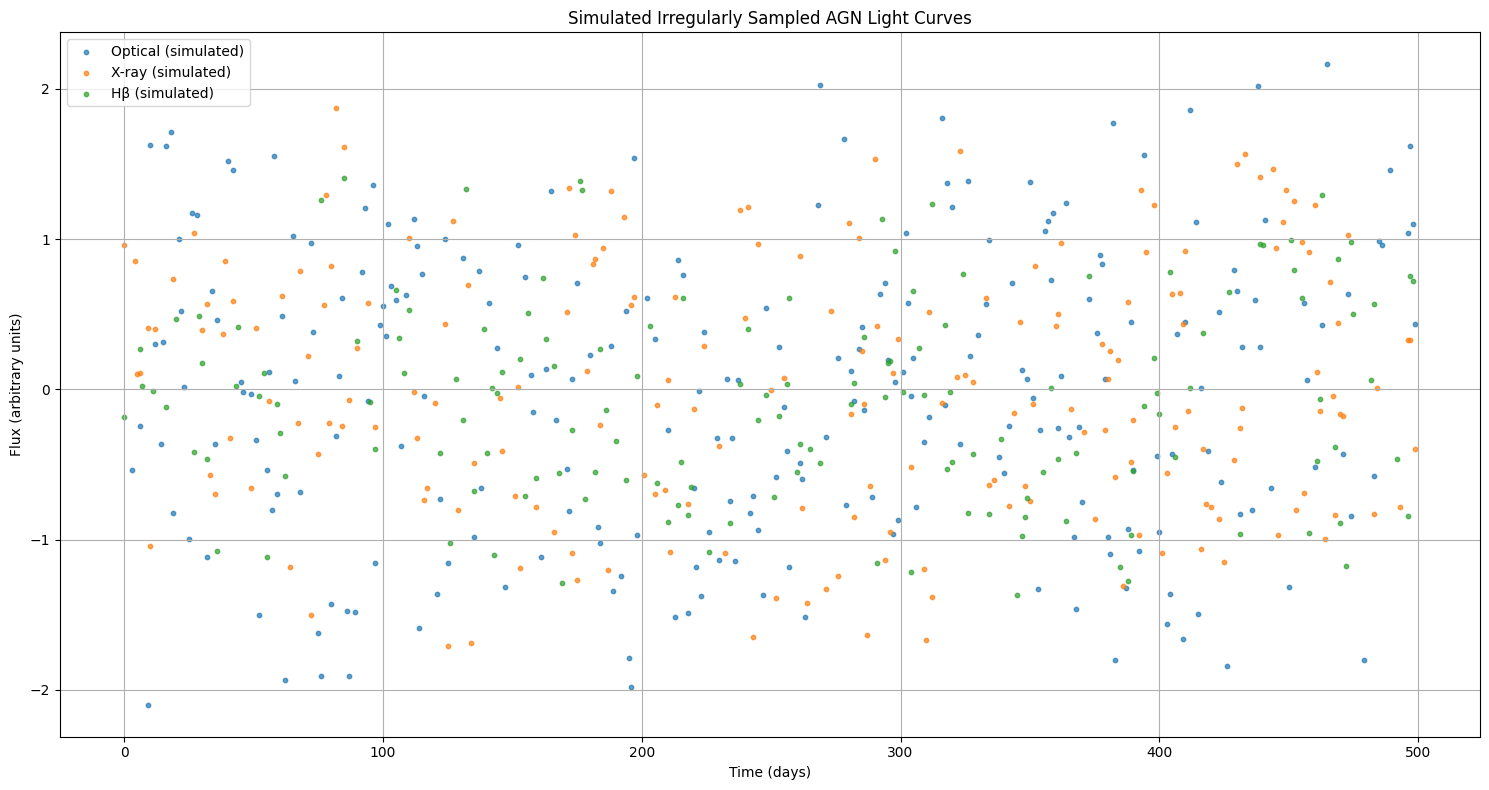

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generate synthetic AGN-like data ---
# Define simulation parameters
N_total_days = 500  # Total duration in days
observation_frequency_opt = 0.5 # 50% of days have optical observations
observation_frequency_xray = 0.4 # 40% of days have X-ray observations
observation_frequency_hbeta = 0.3 # 30% of days have Hbeta observations
mean_lag_days = 20 # Average lag for Hbeta response in days

np.random.seed(43) # For reproducibility

# 1. Simulate an underlying continuum driver (e.g., a random walk)
driver_time = np.arange(N_total_days)
# Smooth random walk as a driver
driver_signal = np.cumsum(np.random.normal(0, 0.1, N_total_days))
driver_signal = (driver_signal - driver_signal.mean()) / driver_signal.std()


# 2. Simulate Optical continuum light curve
time_opt_all = driver_time
flux_opt_all = driver_signal + np.random.normal(0, 0.15, N_total_days)
# Introduce irregular sampling
opt_indices = np.random.choice(N_total_days, int(N_total_days * observation_frequency_opt), replace=False)
time_opt = np.sort(time_opt_all[opt_indices])
flux_opt = flux_opt_all[opt_indices]

# 3. Simulate X-ray continuum light curve
time_xray_all = driver_time
flux_xray_all = 0.8 * driver_signal + np.random.normal(0, 0.2, N_total_days)
# Introduce irregular sampling
xray_indices = np.random.choice(N_total_days, int(N_total_days * observation_frequency_xray), replace=False)
time_xray = np.sort(time_xray_all[xray_indices])
flux_xray = flux_xray_all[xray_indices]


# 4. Simulate Hβ emission line light curve (delayed response to optical)
hbeta_driver_signal = np.interp(driver_time, time_opt_all, flux_opt_all) # Use full optical for Hbeta driver
hbeta_response = np.zeros(N_total_days)
# Apply a simple delay
hbeta_response[mean_lag_days:] = hbeta_driver_signal[:-mean_lag_days] * 0.7 + np.random.normal(0, 0.1, N_total_days - mean_lag_days)
hbeta_response[:mean_lag_days] = np.random.normal(0, 0.1, mean_lag_days) # Noise at the beginning

time_hbeta_all = driver_time
flux_hbeta_all = hbeta_response
# Introduce irregular sampling
hbeta_indices = np.random.choice(N_total_days, int(N_total_days * observation_frequency_hbeta), replace=False)
time_hbeta = np.sort(time_hbeta_all[hbeta_indices])
flux_hbeta = flux_hbeta_all[hbeta_indices]

# --- Visualize the raw, irregularly sampled light curves ---
plt.figure(figsize=(15, 8))
plt.scatter(time_opt, flux_opt, label='Optical (simulated)', s=10, alpha=0.7)
plt.scatter(time_xray, flux_xray, label='X-ray (simulated)', s=10, alpha=0.7)
plt.scatter(time_hbeta, flux_hbeta, label='Hβ (simulated)', s=10, alpha=0.7)
plt.xlabel('Time (days)')
plt.ylabel('Flux (arbitrary units)')
plt.title('Simulated Irregularly Sampled AGN Light Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Now, we will use the `prepare_agn_timeseries` function to resample these irregularly sampled light curves onto a uniform time grid and standardize them. This is the format required for the SURD analysis.

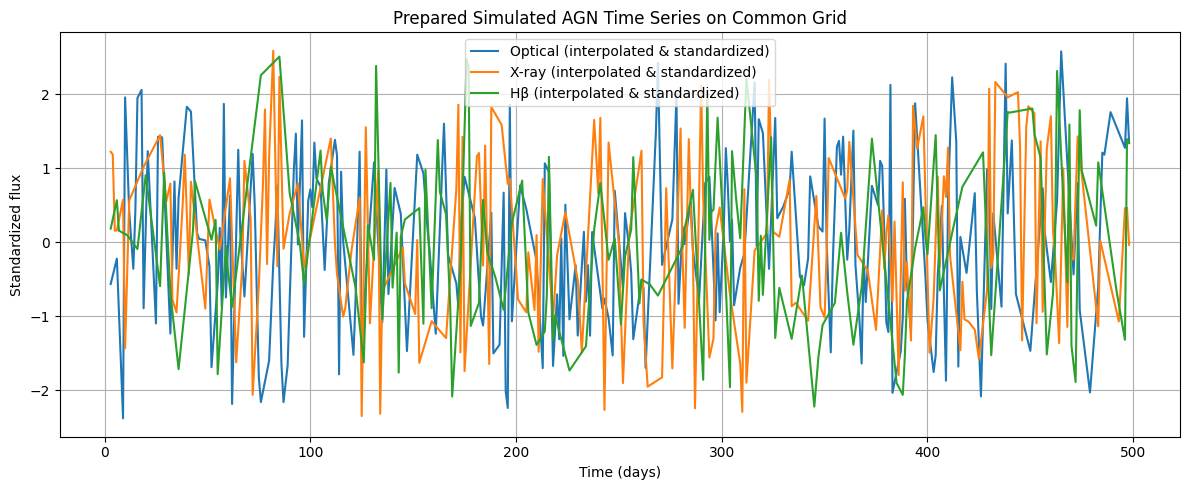

In [8]:
# Choose a uniform grid spacing (e.g., 1 day cadence)
dt = 1.0

# Prepare the three aligned standardised bands using the helper function
grid, X_real_simulated = prepare_agn_timeseries(
    time_opt, flux_opt,
    time_xray, flux_xray,
    time_hbeta, flux_hbeta,
    dt=dt
)

# --- Visual sanity check of the interpolated / standardised signals ---
plt.figure(figsize=(12, 5))
plt.plot(grid, X_real_simulated[0], label='Optical (interpolated & standardized)')
plt.plot(grid, X_real_simulated[1], label='X-ray (interpolated & standardized)')
plt.plot(grid, X_real_simulated[2], label='Hβ (interpolated & standardized)')
plt.xlabel('Time (days)')
plt.ylabel('Standardized flux')
plt.title('Prepared Simulated AGN Time Series on Common Grid')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Finally, we can run the SURD lag scan on this prepared simulated dataset. We'll define a range of lags in *samples* (which, with `dt=1.0` day, corresponds directly to days) and use the `lag_scan_target3` and `plot_lag_metrics` functions.

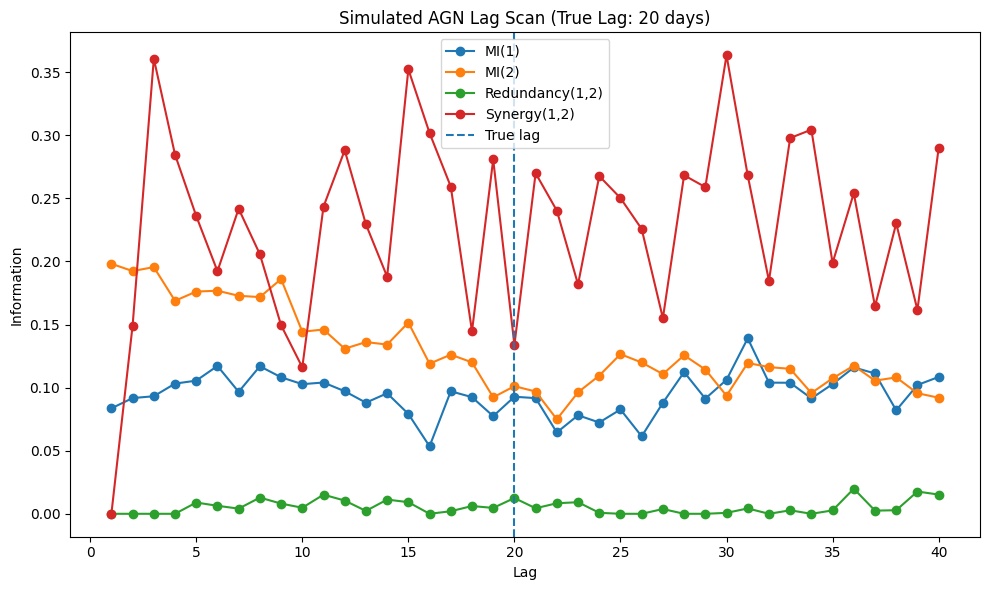

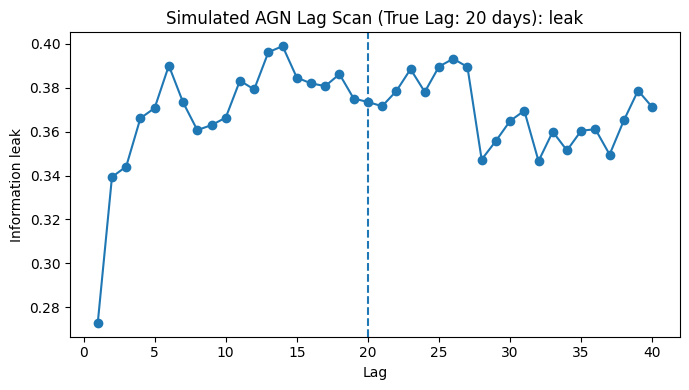


--- Interpretation Reminder ---
   - U1 / MI1 near a lag: Optical carries predictive Hβ information.
   - U2 / MI2 near a lag: X-ray carries predictive Hβ information.
   - R12: Optical and X-ray are redundant proxies for a hidden driver.
   - S12: Combining Optical and X-ray helps more than either alone (non-linear).
   - High leak: Substantial Hβ variability remains unexplained by observed bands.
Keep in mind this is simulated data; real data patterns can be more complex!


In [9]:
# Define lag range in samples (corresponding to days since dt=1.0)
# We'll scan around our expected lag of 20 days.
lags_simulated = np.arange(1, 2 * int(mean_lag_days / dt) + 1)

# Run SURD lag scan on the emission-line target (index 2 for Hβ)
metrics_real_simulated = lag_scan_target3(X_real_simulated, lags_simulated, nbins=8)

# Plot the results
plot_lag_metrics(
    metrics_real_simulated,
    true_tau=int(mean_lag_days / dt),
    title=f'Simulated AGN Lag Scan (True Lag: {mean_lag_days} days)'
)

print("\n--- Interpretation Reminder ---")
print("   - U1 / MI1 near a lag: Optical carries predictive Hβ information.")
print("   - U2 / MI2 near a lag: X-ray carries predictive Hβ information.")
print("   - R12: Optical and X-ray are redundant proxies for a hidden driver.")
print("   - S12: Combining Optical and X-ray helps more than either alone (non-linear).")
print("   - High leak: Substantial Hβ variability remains unexplained by observed bands.")
print("Keep in mind this is simulated data; real data patterns can be more complex!")


In [5]:
# SDSS
# Install astroquery
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.1 MB/s eta 0:00:00


In [6]:
from astroquery.sdss import SDSS
import astropy.units as u
from astropy.coordinates import SkyCoord

# Define the coordinates of an example AGN (e.g., NGC 5548)
# (These are example coordinates, you'd replace them with your target of interest)
ra = 213.915263 * u.deg
dec = 2.784400 * u.deg
coords = SkyCoord(ra, dec, frame='icrs')

# Query for spectroscopic data within a certain radius
# This will return a table of spectroscopic observations.
# For SURD, you'd typically need *time-series* spectroscopic or photometric data.
spec_data = SDSS.query_region(coords, radius=1*u.arcmin, spectro=True)

print("Example SDSS Spectroscopic Data Query Results:")
if spec_data is not None:
    print(spec_data[0:5]) # Print first 5 rows
    print(f"\nFound {len(spec_data)} spectroscopic observations in the region.")
    # To get the actual spectra, you'd use SDSS.get_spectra(matches=spec_data[<index>])
else:
    print("No spectroscopic data found for this region.")

print("\nFor reverberation mapping light curves, you typically need to look for data from dedicated AGN monitoring campaigns. These often involve multiple telescopes observing the same object over extended periods to capture variability in different bands (e.g., optical continuum, X-ray continuum, H-beta emission line). Data archives like those from the AGN Watch consortium or individual paper data releases are good places to start for such specialized datasets.")

Example SDSS Spectroscopic Data Query Results:
       ra              dec       ...     specobjid      run2d
---------------- --------------- ... ------------------ -----
213.928461874832 2.7804568465062 ... 600236900074153984    26

Found 1 spectroscopic observations in the region.

For reverberation mapping light curves, you typically need to look for data from dedicated AGN monitoring campaigns. These often involve multiple telescopes observing the same object over extended periods to capture variability in different bands (e.g., optical continuum, X-ray continuum, H-beta emission line). Data archives like those from the AGN Watch consortium or individual paper data releases are good places to start for such specialized datasets.
